# **Design a Framework for Machin Learing Model for ServiceFirst**

## 1.Business Understanding :

#### **1.1.Background**

ServiceFirst is a national equipment servicing company with 250 employees, including remote and office-based staff. Following the pandemic, the company has experienced high staff turnover, increased recruitment costs and leading to a loss of in-house experience.

To address this issue, the People & Culture (P&C) team surveyed employees to measure employee satisfaction and organizational climate perceptions. Now, they seek to apply advanced analytics and machine learning to uncover key drivers of satisfaction and identify factors influencing employee retention.

ServiceFirst has a total of 250 employees, out of which 196 participated in the survey. Among those respondents, 142 granted permission for their data to be used in the P&C research project.

ServiceFirst has shared their Dataset for us to work with: **metadata_employee_survey.csv** & **employee_survey.csv**

#### **1.2.Business Objectives:**

•	Identify key drivers of employee satisfaction.

•	Establish relationships between demographic factors and satisfaction scores.

•	Determine predictive factors affecting employee retention (intention to leave).

•	Provide actionable recommendations to improve employee satisfaction and retention.



#### **1.3.Assess the Situation**

**Demographic Data:**

`workloc` (1 = Remote, 2 = Office-based)

`workleng` (Length of service)

`manag_resp` (Managerial responsibility)

**Satisfaction Scores (Key Focus Areas):**

`involved`: Feeling of involvement in decisions.

`autonomy`: Feeling trusted by the organization.

`direct_manag`: Relationship with direct managers.

`integrated`: Team cohesion.

`welfare`: Feeling valued by the organization.

`training`: Perception of sufficient training.

`work_press`: Work-life balance.

`reflexive`: Adaptability to external changes.

`innovative`: Innovation encouragement.

`customers`: Organization's response to customer needs.

**Outcome Variables:**

`overall_score`: Sum of satisfaction scores.

`intent_quit`: Intention to leave (1 = Yes, 2 = No, 3 = Not Sure).

`sentiment`: Coded sentiment analysis (1 = Negative, 2 = Neutral, 3 = Positive).




## **2.Data Understanding**


### **2.1.Import the Data(Data collection)**


 Begin by Importing the data and necesary lirarires , later examining it to identify necessary cleaning methods and enhancements that will improve its quality to suit the analysis needs.
 
 **Pandas** is used for data manipulation and analysis because it provides powerful, flexible, and efficient tools for handling structured data. Key reasons to use Pandas:
 
 **Data Handling** – Easily read and write data from CSV, Excel, SQL, JSON, etc.
 
 **NumPy** is used for numerical computing in Python because it provides fast, efficient, and flexible operations on large datasets. Key reasons to use NumPy:

**Efficient Data Storage** – Uses arrays (ndarray) that are more memory-efficient than Python lists.
**Fast Computations** – Optimized for mathematical operations, making it much faster than loops.

 • Import the `Pandas` and `NumPy` libraries.

 • Create new variables employee_data and metadata to store the data set.

 • Import the data set with Pandas and create a DataFrame.



In [1747]:
# Import the necessary libraries, packages, and modules.
import pandas as pd
import numpy as np

# Import the employee survey dataset and call them employee_data and metadata
employee_data = pd.read_csv("employee_survey.csv")
metadata = pd.read_csv("metadata_employee_survey.csv")


### **2.2.Explore the data** 
 Perform exploratory data analysis (EDA).
 
 The `info(`), `head()`, and `describe()` methods are essential for Exploratory Data Analysis (EDA) because they provide a quick overview of the   dataset:

**info()** – Displays the structure of the dataset, including column names, data types, and missing values.

**head()** – Shows the first few rows, giving a quick preview of the dataset’s contents.

These methods help in understanding data quality, detecting anomalies, and guiding further cleaning and analysis.

In [1674]:
# Perform EDA on the DataFrame.
print(employee_data.head())
print(employee_data.info())


   id agree  workloc  workleng  manag_resp  involved  autonomy  direct_manag  \
0   1   Yes        2         3           2  3.195169  3.879956      1.343400   
1   2   Yes        1         3           2 -1.017589  0.613432      1.053927   
2   8   Yes        1         3           2  1.510066  0.613432     -2.419751   
3  15   Yes        1         3           2  1.088790 -0.475410     -1.551332   
4  20   Yes        2         3           2 -0.596313 -1.564251     -0.393439   

   integrated   welfare  training  work_press  reflexive  innovative  \
0    4.920832  2.623486  4.476097    3.903101   2.996662   -2.256064   
1   -0.147223  1.073410 -1.106388   -0.705966   2.004760   -1.880934   
2    0.486283  0.040025 -0.308890    1.598567  -1.466898    0.744976   
3   -0.780730 -1.510051 -1.106388   -0.129833  -1.218922    1.120106   
4   -0.147223  0.040025  0.488608   -0.129833   0.268931    0.744976   

   customers  overall_score  intent_quit  sentiment  
0   2.736050          27.82     

According to employee_data set has 142 rows and 18 columns,
And data types are float64, int64 and object.

### **2.3.Compute descriptive statistics**

The `describe()` method is used to generate summary statistics for numerical columns in a DataFrame. It provides key insights such as count, mean, standard deviation, minimum, maximum, and quartiles, helping to understand data distribution and detect anomalies.

In [1678]:
#Generate descriptive statistics using the describe() method.
employee_data.describe() 

,id,workloc,workleng,manag_resp,involved,autonomy,direct_manag,integrated,welfare,training,work_press,reflexive,innovative,customers,overall_score,intent_quit,sentiment
count,142.000000,142.000000,142.000000,142.000000,1.420000e+02,1.420000e+02,1.420000e+02,1.420000e+02,1.420000e+02,1.420000e+02,1.420000e+02,1.420000e+02,1.420000e+02,1.420000e+02,142.000000,142.000000,142.000000
mean,94.450704,1.669014,9.584507,1.739437,-4.225355e-11,1.126760e-10,1.056338e-10,-7.746481e-11,1.126761e-10,9.859157e-11,-1.338029e-10,1.408450e-11,7.042232e-12,-7.042279e-12,-0.000493,1.732394,1.971831
std,55.642549,0.472234,4.588365,0.440496,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,4.158789,0.703744,0.704028
min,1.000000,1.000000,3.000000,1.000000,-3.545243e+00,-3.197513e+00,-2.998698e+00,-2.681251e+00,-3.060127e+00,-3.498881e+00,-3.586633e+00,-1.466898e+00,-2.631194e+00,-2.741193e+00,-11.680000,1.000000,1.000000
25%,48.250000,1.000000,8.000000,1.000000,-5.963129e-01,-4.754096e-01,-6.105439e-01,-7.807303e-01,-4.766666e-01,-3.088900e-01,-7.059663e-01,-7.229710e-01,-7.555435e-01,-5.502959e-01,-2.497500,1.000000,1.000000
50%,94.500000,2.000000,8.000000,2.000000,3.560077e-02,6.901107e-02,-1.039657e-01,-1.472234e-01,4.002544e-02,-3.088900e-01,1.582338e-01,2.095568e-02,-5.283521e-03,1.800033e-01,-0.270000,2.000000,2.000000
75%,138.750000,2.000000,13.000000,2.000000,6.675144e-01,6.134318e-01,9.815588e-01,4.862834e-01,5.567175e-01,4.886078e-01,4.463005e-01,5.169068e-01,7.449765e-01,5.451529e-01,2.455000,2.000000,2.000000
max,194.000000,2.000000,23.000000,2.000000,3.195169e+00,3.879956e+00,1.343400e+00,4.920832e+00,2.623486e+00,4.476097e+00,3.903101e+00,2.996662e+00,1.495236e+00,2.736050e+00,27.820000,3.000000,3.000000





**Summary Statistics**

• The satisfaction scores appear to be standardized (mean ~ 0, std ~ 4).

• Overall satisfaction scores range from -11.68 to 11.68(except one extreme outlier).

• Intent to quit: Most employees are unsure or do not intend to quit.

• Sentiment Analysis: Scores range from 1 to 3 .



### **2.4 Verifying Data Quality** 
#### Determine if there are missing values
Why Check for Missing Values?

Detect Data Gaps – Identifies columns with missing (NaN) values.

Understand Data Quality – Helps assess completeness before analysis.

Plan Data Cleaning – Determines if missing values should be removed or imputed.

Avoid Errors – Prevents issues in calculations, visualizations, and machine learning models.

Using `isnull()`provides a quick summary of missing values in each column, ensuring data reliability.

Check for missing values with the `isnul().sum()` method.

In [1682]:
employee_data.isnull().sum()

id               0
agree            0
workloc          0
workleng         0
manag_resp       0
involved         0
autonomy         0
direct_manag     0
integrated       0
welfare          0
training         0
work_press       0
reflexive        0
innovative       0
customers        0
overall_score    0
intent_quit      0
sentiment        0
dtype: int64

**No missing value**

#### Determine if there are Duplicate**

Why Identify Duplicate Rows?

**Ensures Data Integrity** – Avoids biased or misleading analysis.

**Prevents Data Redundancy** – Eliminates unnecessary duplication.

**Improves Model Accuracy** – Ensures unique data points for training.

**Optimizes Performance** – Reduces dataset size and enhances processing speed.

- Steps to Identify Duplicate Rows:

Apply `duplicated()` Method to the dataset.


Check patterns in repeated values before deciding on removal.

- Decision on Next Steps:

Drop duplicates (.drop_duplicates()) if unnecessary.

Retain duplicates if valid (e.g., repeated survey responses).

Checking for duplicates maintains clean, accurate, and meaningful data. 

In [1686]:
# Identify duplicate rows.
employee_data[employee_data.duplicated()]

,id,agree,workloc,workleng,manag_resp,involved,autonomy,direct_manag,integrated,welfare,training,work_press,reflexive,innovative,customers,overall_score,intent_quit,sentiment


**No duplicate**


### **2.5.Correlation between variables** 
#### Explore distribution of key variables and correlation between them (bar plots , heatmap, boxplot, histograms ).

***To Inspect the correlation between variables we need to transform some columns data type, thus performing the Integrate and formating step here otherwise we will expect an error for data type.**

**Integrate and Formating**

Before inspecting the correlation, the data needs to be properly formatted to ensure compatibility for correlation analysis.

Why Convert Categorical Variables to Numerical Representations?

Prepares Data for Analysis & Modeling – Many machine learning models and statistical techniques require numerical inputs.

Improves Consistency – Standardizes categorical responses for easy interpretation.

Avoids Errors – Ensures categorical columns are correctly typed to prevent processing issues.

Follow the Step-by-Step Instructions:

Convert Binary Categories to Numeric Values: Use `map()` to transform `"Yes" : 1` and `"No" : 0` in the agree column.

Define Categorical Columns: Identify columns (`workloc, workleng, manag_resp, intent_quit, sentiment`) that should be categorical.

Change Data Type to `'Category'`: Use .astype('category') to ensure correct data type, preventing errors.

Verify Changes: Use `info()` to confirm data types and check for missing values.

This ensures structured, clean, and machine-learning-ready data

In [1749]:
# Convert categorical variables to numerical representations
# Mapping 'agree' column (Yes = 1, No = 0)
employee_data['agree'] = employee_data['agree'].map({'Yes': 1, 'No': 0})  

# Ensure categorical columns are correctly typed
categorical_columns = ['workloc', 'workleng', 'manag_resp', 'intent_quit', 'sentiment'] 
employee_data[categorical_columns] = employee_data[categorical_columns].astype('category')
# previously received an typo error for these columns hence changing their types to thier correct one which is category  



# Display cleaned data info and missing values
employee_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142 entries, 0 to 141
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   id             142 non-null    int64   
 1   agree          142 non-null    int64   
 2   workloc        142 non-null    category
 3   workleng       142 non-null    category
 4   manag_resp     142 non-null    category
 5   involved       142 non-null    float64 
 6   autonomy       142 non-null    float64 
 7   direct_manag   142 non-null    float64 
 8   integrated     142 non-null    float64 
 9   welfare        142 non-null    float64 
 10  training       142 non-null    float64 
 11  work_press     142 non-null    float64 
 12  reflexive      142 non-null    float64 
 13  innovative     142 non-null    float64 
 14  customers      142 non-null    float64 
 15  overall_score  142 non-null    float64 
 16  intent_quit    142 non-null    category
 17  sentiment      142 non-null    cate

**The following columns type has been changed to "Category":**

Workloc , workleng , manag_resp , intent_quit , sentiment .


The `corr()` method is used to calculate the correlation between numerical variables in a dataset.

**Identifying Relationships** – Measures how strongly features are related (positive, negative, or no correlation).

**Feature Selection** – Helps in choosing important variables for modeling.
                                                         
**Detecting Multicollinearity** – Finds highly correlated features that may affect model performance.
                                                         
It is essential for EDA and predictive analytics to understand dependencies between variables.

Use `corr()` method to check the correlations and `round()` method to round up the out put (e.g. 2)

In [1751]:
# Compute the correlation between variables rounded to two decimal places.
correlation_matrix= employee_data.corr().round(2)

# Display correlation matrix
correlation_matrix

,id,agree,workloc,workleng,manag_resp,involved,autonomy,direct_manag,integrated,welfare,training,work_press,reflexive,innovative,customers,overall_score,intent_quit,sentiment
id,1.00,NaN,-0.09,0.18,-0.02,-0.10,0.07,0.04,-0.00,0.01,-0.06,-0.02,-0.09,0.08,0.01,-0.01,-0.07,-0.07
agree,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
workloc,-0.09,NaN,1.00,-0.10,0.06,-0.00,-0.05,0.03,0.05,0.09,0.13,-0.02,0.18,-0.16,0.04,0.07,0.12,-0.07
workleng,0.18,NaN,-0.10,1.00,0.05,-0.15,0.07,0.00,0.12,-0.03,0.00,0.08,0.05,0.04,-0.02,0.04,-0.23,0.08
manag_resp,-0.02,NaN,0.06,0.05,1.00,-0.04,-0.02,-0.02,-0.02,0.06,0.11,0.13,0.06,0.11,0.04,0.10,0.09,0.04
involved,-0.10,NaN,-0.00,-0.15,-0.04,1.00,0.11,-0.09,0.13,-0.10,0.14,0.29,-0.15,0.13,0.37,0.44,0.05,0.07
autonomy,0.07,NaN,-0.05,0.07,-0.02,0.11,1.00,0.17,0.20,0.22,0.28,0.28,0.22,-0.10,0.13,0.61,-0.04,0.02
direct_manag,0.04,NaN,0.03,0.00,-0.02,-0.09,0.17,1.00,0.14,0.43,0.19,-0.05,0.36,-0.24,-0.11,0.43,0.03,0.00
integrated,-0.00,NaN,0.05,0.12,-0.02,0.13,0.20,0.14,1.00,0.22,0.20,0.15,0.40,-0.16,0.04,0.56,0.02,0.08
welfare,0.01,NaN,0.09,-0.03,0.06,-0.10,0.22,0.43,0.22,1.00,0.27,-0.07,0.45,-0.39,-0.30,0.41,0.07,0.02


**Use Visualisation to gain insight for the following factors:**

 - Explore correlations between factors influencing employee satisfaction(using Heatmap).

 - Visualize satisfaction levels across work locations and managerial responsibilities.

 - Analyze intent to quit trends across different groups.

 - Gain insight of the data distibution Skewness and Kurtosis and outliers.

 Visualization is used to interpret data quickly and effectively by transforming raw numbers into graphical insights,
 simplifies complex data and makes analysis more intuitive and impactful.

**Import necessary librarires:**

`Matplotlib` and `Seaborn` are used for data visualization in Python:


**Matplotlib (plt)** – A flexible, low-level library for creating basic plots (line, bar, scatter, histogram, etc.). It provides full control over chart customization.

**Seaborn (sns)** – Built on top of Matplotlib, it simplifies statistical visualizations with better aesthetics and built-in themes. It is great for correlation heatmaps, violin plots, and distribution plots.

Together, they help in data exploration, trend identification, and presentation-quality charts.

Create the heatmap → sns.heatmap(data.corr(), annot=True, cmap="coolwarm")


Uses `corr()` to compute correlation between numerical variables.

`annot=True ` displays values inside the heatmap.

`cmap="coolwarm"` sets the color scheme.

Customize title : `plt.title`("Correlation Heatmap") (Adds a title).

Show the heatmap : `plt.show()` (Displays the visualization).

**Using  the simillar for the rest figures:**

Set figure size : `plt.figure(figsize=(8, 5))` (Defines the plot size).

Create count plot : `sns.countplot()` (Counts occurrences of "Intention_to_quit" for each "Work_location").

Customize x-axis labels : `plt.xticks()` (Renames 0, 1, 2 to "Yes", "No", "Not Sure").

Label axes : `plt.xlabel()` & `plt.ylabel()` (Sets x-axis and y-axis labels).

Add title : `plt.title()` (Gives the plot a descriptive title).

Customize legend : `plt.legend()` (Renames legend labels to "Remote" and "Office-Based").

Display the plot : `plt.show()` (Renders the visualization).

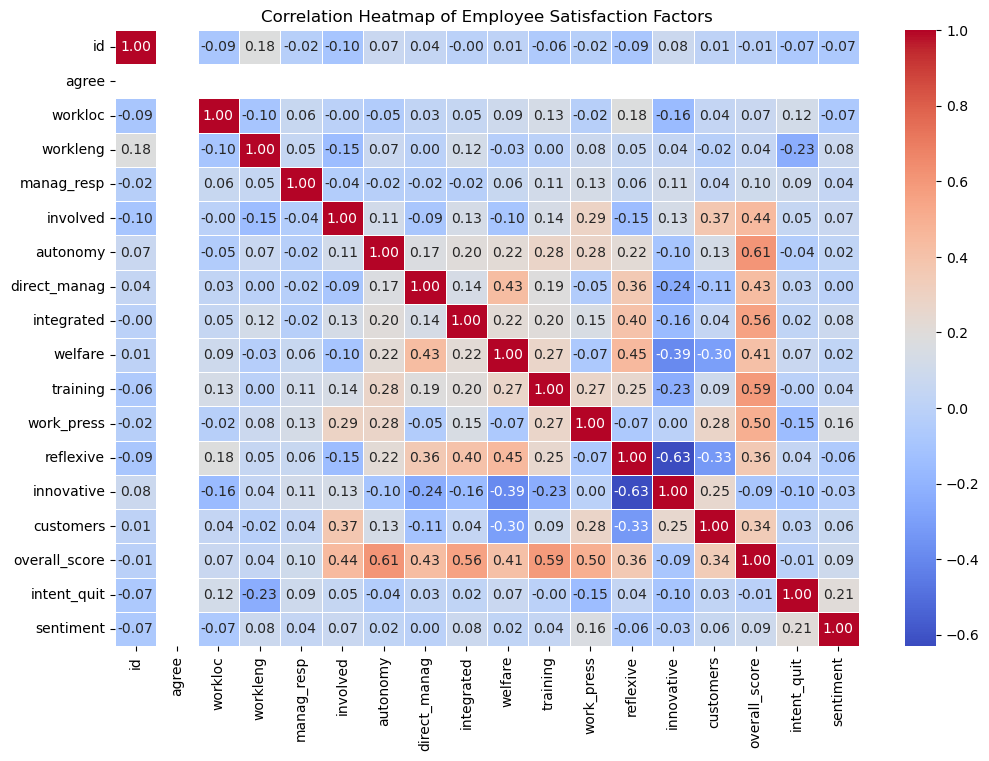

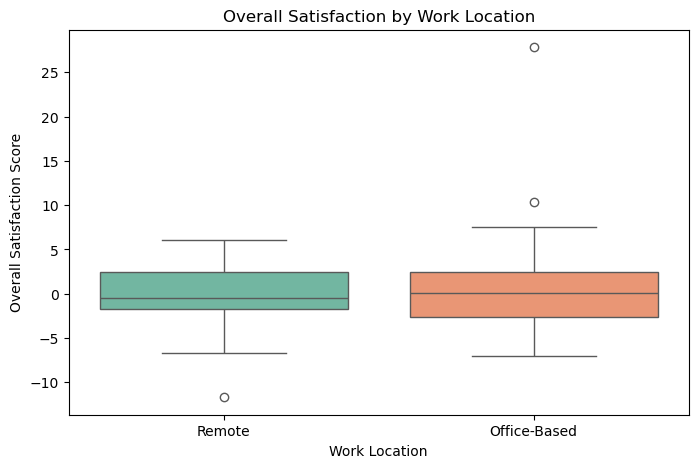

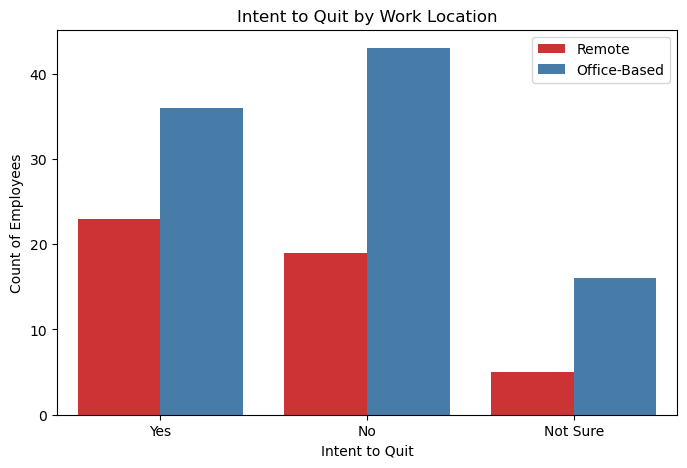

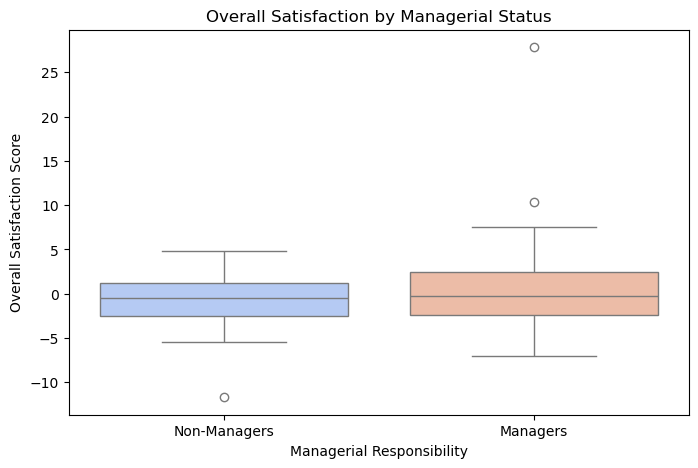

In [1753]:
#Import Seaborn and Matplotlib librarires
import matplotlib.pyplot as plt
import seaborn as sns

#Import Warnings to filter unecessary warning
import warnings
warnings.filterwarnings('ignore')


# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Employee Satisfaction Factors")
plt.show()


# Identify strongest correlations with overall_score
correlation_with_overall = correlation_matrix["overall_score"].sort_values(ascending=False)

#Display output
correlation_with_overall


# Distribution of Overall Satisfaction Scores by Work Location
plt.figure(figsize=(8, 5))
sns.boxplot(x="workloc", y="overall_score", data=employee_data, palette="Set2")
plt.xticks([0, 1], ["Remote", "Office-Based"])
plt.xlabel("Work Location")
plt.ylabel("Overall Satisfaction Score")
plt.title("Overall Satisfaction by Work Location")
plt.show()

# Distribution of Intent to Quit by Work Location
plt.figure(figsize=(8, 5))
sns.countplot(x="intent_quit", hue="workloc", data=employee_data, palette="Set1")
plt.xticks([0, 1, 2], ["Yes", "No", "Not Sure"])
plt.xlabel("Intent to Quit")
plt.ylabel("Count of Employees")
plt.title("Intent to Quit by Work Location")
plt.legend(["Remote", "Office-Based"])
plt.show()

# Distribution of Overall Satisfaction by Managerial Status
plt.figure(figsize=(8, 5))
sns.boxplot(x="manag_resp", y="overall_score", data=employee_data, palette="coolwarm")
plt.xticks([0, 1], ["Non-Managers", "Managers"])
plt.xlabel("Managerial Responsibility")
plt.ylabel("Overall Satisfaction Score")
plt.title("Overall Satisfaction by Managerial Status")
plt.show()

**Key Insights from Exploratory Data Analysis (EDA)**

**Correlation Analysis:**

overall_score    1.000000

autonomy         0.605272

training         0.592758

integrated       0.557706

work_press       0.502108

involved         0.440264

direct_manag     0.430010

welfare          0.414158

reflexive        0.358930

customers        0.342692

manag_resp       0.095283

sentiment        0.089620

workloc          0.070083

workleng         0.040367

id              -0.013515

intent_quit     -0.013640

innovative      -0.085480


#### Key Findings from Correlation Analysis:

  **Strongest Positive Correlations with Employee Satisfaction (overall_score):**

Autonomy `(0.605)` → Employees feeling trusted by the organization correlates highly with satisfaction.

Training `(0.593)` → Employees who feel they get enough training report higher satisfaction.

Integration in Teams `(0.558)` → Strong team dynamics contribute to overall satisfaction.

Work Pressure `(-0.502)` → Indicates that better work-life balance correlates with satisfaction.

Involvement in Decisions `(0.440)` → Feeling involved in decisions contributes positively.

  **Weaker or Negative Correlations:**

Managerial Responsibility `(0.095)` and Work Location `(0.070)` show low correlation.

Intention to Quit `(-0.014)` and Innovative Culture `(-0.085)` have weak or slightly negative relationships with satisfaction.

Sentiment `(0.089)` has a low correlation, suggesting that employee sentiment alone doesn’t fully determine satisfaction.



**Work Location & Satisfaction:**

`Remote` employees seem to have lower satisfaction scores than `office-based` employees.

This suggests that remote workers may feel less engaged or supported.

**Intent to Quit & Work Location:**

`Remote` workers are more likely to be in the`"Yes"` (considering leaving) and `Office_based` in the `"No"` or `"Not Sure"` category.

`Office-based` employees tend to be more stable in their employment intentions.

**Managerial Responsibility & Satisfaction:**

`Managers` generally report higher overall satisfaction scores compared to `non-managers`.

This might indicate better engagement, career growth, or resources for managerial roles.


### **2.6.Skewness and Kurtosis**

Skewness and kurtosis are used to understand the shape and distribution of data:

**Skewness** – Measures asymmetry in data distribution.

Positive skew: Tail is on the right (high values).

Negative skew: Tail is on the left (low values).

**Kurtosis** – Measures tailedness (peak/sharpness of distribution).

High kurtosis: More extreme outliers .

Low kurtosis: Fewer extreme values.

Both help in detecting outliers, data normality, and model assumpt

#### Use Histogram to visually inspect the skewness and Kurtosis of the variables

- Select Relevant Columns and call it `distribution`: Identify key satisfaction factors to analyze their distribution.
Include Overall_score and other numerical variables from employee_data.

- Set Figure Size : Define a suitable plot size for clear visualization.`plt.figure(figsize=(12, 8))`

- Create Histograms: Generate histograms for all selected numerical variables. Use bins to group data and edge color to enhance readability.

- Add Title: Label the chart as "Distribution of Numerical Features" for clarity.

- Adjust Layout: Ensure proper spacing and alignment of plots for better visualization.

- Display the Plot: Render the histogram to analyze distributions of key factors. Use `tight_layout()` to auto fit them.

<Figure size 1200x800 with 0 Axes>

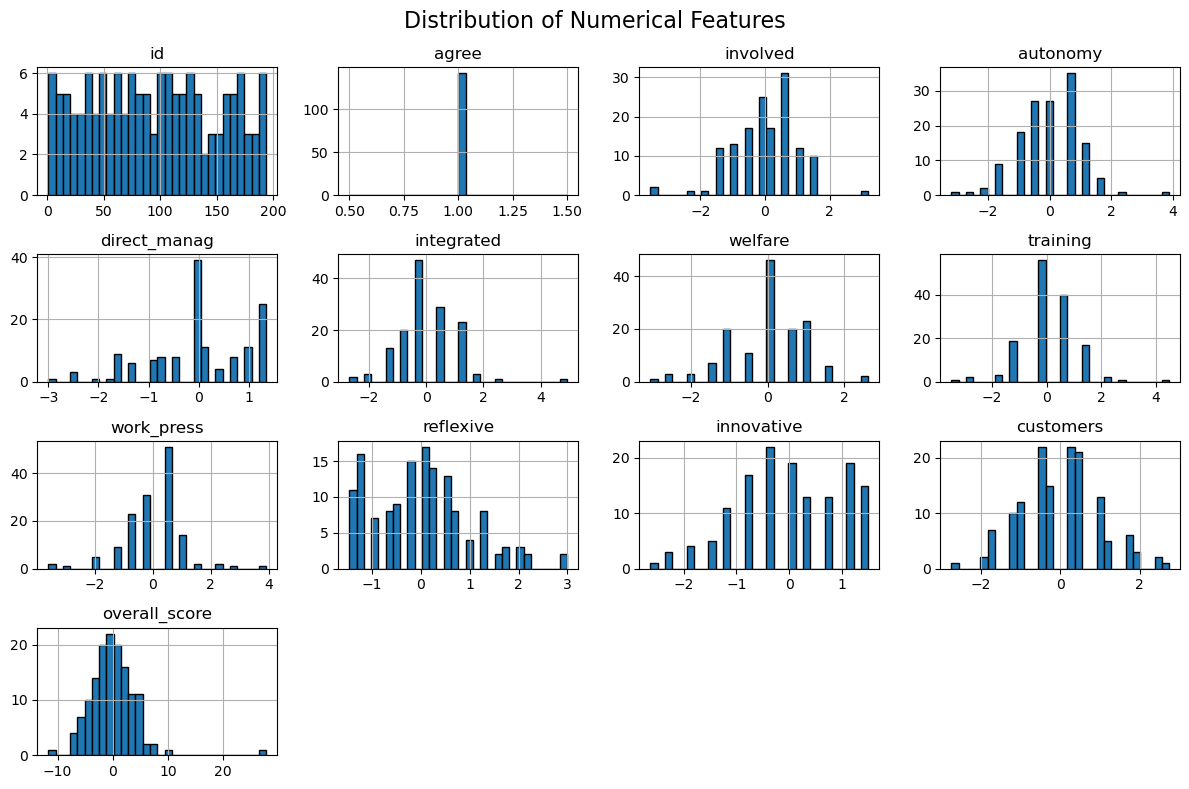

In [1703]:




# Plot distribution of numerical variables
plt.figure(figsize=(12, 8))
employee_data.hist(bins=30, figsize=(12, 8), edgecolor='black')
plt.suptitle("Distribution of Numerical Features", fontsize=16)

  
# Adjust layout
plt.tight_layout()
plt.show()



**Distributions of numerical variables:**

Some variables appear normally distributed(e.g.  `customers` , `Automomy` ..), while others show skewed patterns(e.g.` overall_score`,`innovative` , `direct_manag` ...).

`overall_score` has a wide range, which might indicate varied satisfaction levels among employees and the skewness to the left(posiible outlier).


#### Calculate the Skewness and Kurtosis

**Follow the steps:**

- Import Required Library

Load `scipy.stats` to compute skewness and kurtosis.

- Initialize Storage for Results

Create an empty list to store skewness and kurtosis values and call it `skew_kurt_values`.

- Loop Through Each Column in factor_columns

Compute skewness using `skew()` method (asymmetry of data distribution).

Compute kurtosis using `kurtosis()` method (tailedness of data distribution).

Store results in a structured format using `append()` method.

- Convert Results to DataFrame

Organize skewness and kurtosis values into a table for easy interpretation and call it `skew_kurt_df`.

- Print the DataFrame

Display the computed skewness and kurtosis for analysis.








In [1756]:
# Import necessary libraries
import scipy.stats as stats

# Compute skewness and kurtosis for each factor
skew_kurt_values = []
for col in factor_columns:
    skewness = stats.skew(employee_data[col])
    kurtosis = stats.kurtosis(employee_data[col])
    skew_kurt_values.append({"Factor": col, "Skewness": skewness, "Kurtosis": kurtosis})

# Convert results into a DataFrame
skew_kurt_df = pd.DataFrame(skew_kurt_values)
print(skew_kurt_df)


           Factor  Skewness   Kurtosis
0        involved -0.488224   1.298795
1        autonomy -0.005517   1.245209
2    direct_manag -0.448278  -0.219670
3      integrated  0.525267   3.431875
4         welfare -0.396828   0.470193
5        training  0.300144   3.296690
6      work_press -0.357701   3.194091
7       reflexive  0.537801   0.024924
8      innovative -0.269892  -0.610587
9       customers  0.138923  -0.048964
10  overall_score  2.015129  12.879576


Histograms were used to visually assess the distribution of satisfaction factors and identify patterns in the data. Specifically, they help to:

**Check Skewness** – Determine if the data is symmetrical or leans to one side (-1 to 1): (Only checking the numerical columns -> factors) 

Right-skewed (positive skew): More values are concentrated on the left.  ` Overall_score`(` 2.015129 `) and `reflexive` variable according to the histogram and calulation `0.447044 ` have positive skewness.

Left-skewed (negative skew): More values are concentrated on the right. Variables: `involved `, `Autonomy`, `direct_manag`,  `welfare`,   `work_press`, `innovative` have a slightly negative skewness byt still within the range of (-1 to 1).

Near zero skew: Data is evenly distributed. Variables:  `customers` show almost no or close to zero skewness.

**Check Kurtosis** – Measure the peakness or flatness of the distribution (-3 to 3): 

High kurtosis (>3): Sharp peak, indicating many extreme values (outliers). `Overall_score` , `work_press` , `training` and `integrated` have a sharp peak, indicating possible outliers.

Low kurtosis (<3): Flat distribution, suggesting few outliers. Variables : `work_press` 2.56 ,`training` 1.58 and `involved ` 1.03 have the highest Kurtosis indicating a peak distribution and thier outliers. The rest of the variables are either close to 0 or 1 which indicate a flat distribution. 

Using histograms along with skewness and kurtosis values helps decide if data transformations are needed to normalize distributions for better modeling performance.

**Conclusion:**

🔹  Skewness and kurtosis indicating possible outliers , the data needs inspection to normalise for statistical analysis.

🔹 After normalising data ,using parametric tests (e.g., t-test, regression), the data should be fine unless the high kurtosis affects variance.

🔹 If extreme outliers cause problems, Winsorization (capping extreme values) might be better than full normalization.

**Next:**

 Data Preparation
 
 Proceed with statistical analysis (hypothesis testing, regression).

 Monitor if high kurtosis affects variance; if necessary, apply Winsorization instead of full normalization.

## **3.Data Preparation**

### **3.1.Clean data**

### **3.1.1.Handeling If there are missing values**

Why Check for Missing Values?

**Detect Data Gaps** – Identifies columns with missing (NaN) values.

**Understand Data Quality** – Helps assess completeness before analysis.

**Plan Data Cleaning** – Determines if missing values should be removed or imputed.

**Avoid Errors** – Prevents issues in calculations, visualizations, and machine learning models.

Using `isnull()`provides a quick summary of missing values in each column, ensuring  data reliability.

Check for missing values with the `isnul().sum()` method.


In [1711]:
# Check for missing values
employee_data.isnull().sum()

id               0
agree            0
workloc          0
workleng         0
manag_resp       0
involved         0
autonomy         0
direct_manag     0
integrated       0
welfare          0
training         0
work_press       0
reflexive        0
innovative       0
customers        0
overall_score    0
intent_quit      0
sentiment        0
dtype: int64

Replace missing value with NA using `fillna()` method If there are any.. 

In [1714]:
employee_data['agree'].fillna(value=True, inplace=True)


Check for changes:

In [1717]:
# Check for missing values
employee_data.isnull().sum()

id               0
agree            0
workloc          0
workleng         0
manag_resp       0
involved         0
autonomy         0
direct_manag     0
integrated       0
welfare          0
training         0
work_press       0
reflexive        0
innovative       0
customers        0
overall_score    0
intent_quit      0
sentiment        0
dtype: int64

**No more missing values**

### **3.1.2.Determine if there are Duplicate**

Why Identify Duplicate Rows?

**Ensures Data Integrity** – Avoids biased or misleading analysis.

**Prevents Data Redundancy** – Eliminates unnecessary duplication.

**Improves Model Accuracy** – Ensures unique data points for training.

**Optimizes Performance** – Reduces dataset size and enhances processing speed.

- Steps to Identify Duplicate Rows:

Apply `duplicated()` Method to the dataset.


Check patterns in repeated values before deciding on removal.

- Decision on Next Steps:

Drop duplicates (.drop_duplicates()) if unnecessary.

Retain duplicates if valid (e.g., repeated survey responses).

Checking for duplicates maintains clean, accurate, and meaningful data. 

In [1721]:
# Identify duplicate rows.
employee_data[employee_data.duplicated()]

,id,agree,workloc,workleng,manag_resp,involved,autonomy,direct_manag,integrated,welfare,training,work_press,reflexive,innovative,customers,overall_score,intent_quit,sentiment


**No duplicate values found in the dataset.**

### **3.1.3.Identifying Outliers**

  - Use boxplots to visually inspect outliers in each numeric column.
 
  - Use the IQR (Interquartile Range) method to detect extreme values.

  - Check distributions of key features to determine whether outliers affect the analysis.

**Handling Outliers**

If significant outliers are found, possible approaches include:
 - Cap extreme values at a percentile threshold. 
 - Removal: Remove outliers if they are clear data entry errors.
 - Transformation: Apply log or normalization techniques if the distribution is highly skewed.


Follow these steps: 

Extracts specific columns from `employee_data` that impact `Overall_score`.

Stores them in `factor_columns`.

Compute Q1 & Q3 " `quantile(0.25)` and `quantile(0.75)`


Finds the 25th percentile (Q1) and 75th percentile (Q3) for each column.

Calculate IQR → `IQR = Q3 - Q1`

Interquartile Range (IQR) measures data spread (middle 50% of values).

Define outlier thresholds"

Lower bound: `Q1 - 1.5 * IQR`

Upper bound: `Q3 + 1.5 * IQR`

Any value outside this range is considered an outlier.

Identify outliers " `(factor_columns < lower_bound) | (factor_columns > upper_bound)`


Creates a Boolean mask `(True for outliers, False otherwise)`.

Count outliers per column " `outliers.sum()`

Sums True values in each column to get the total number of outliers and then visualize.

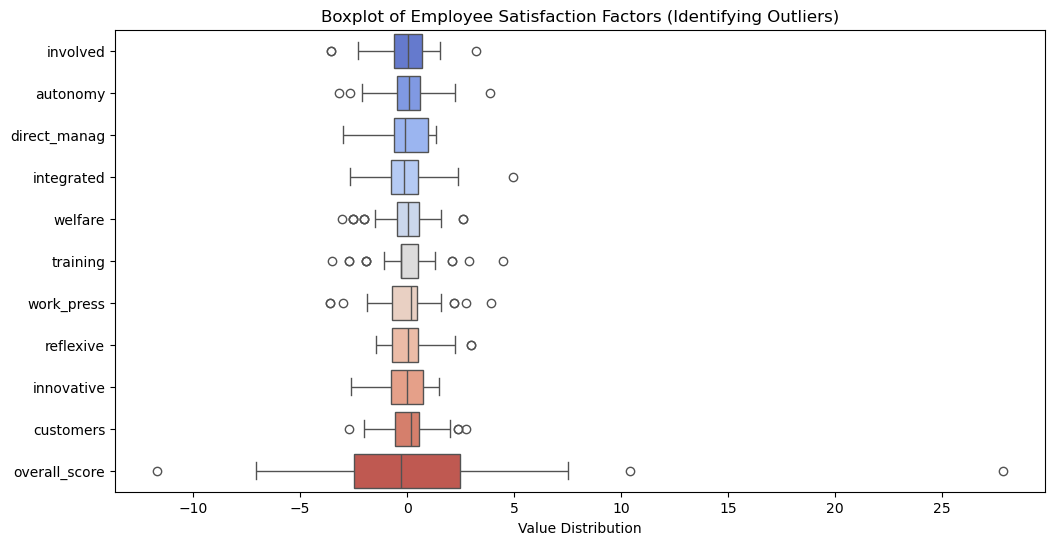

involved          3
autonomy          3
direct_manag      0
integrated        1
welfare           9
training         10
work_press        7
reflexive         2
innovative        0
customers         4
overall_score     3
dtype: int64


In [1758]:
#Create a variable that contains the columns that effects overall score and call it factor_columns 
factor_columns = employee_data[['involved','autonomy',	'direct_manag','integrated','welfare','training','work_press',	
'reflexive','innovative','customers','overall_score']]
## Compute IQR for each column
Q1 = factor_columns.quantile(0.25)
Q3 = factor_columns.quantile(0.75)
IQR = Q3 - Q1

# Define outlier thresholds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = (factor_columns < lower_bound) | (factor_columns > upper_bound)

# Count of outliers per column
outlier_counts = outliers.sum()

# Display outlier summary
# Boxplot visualization for outlier detection
plt.figure(figsize=(12, 6))
sns.boxplot(data=factor_columns, orient="h", palette="coolwarm")
plt.title("Boxplot of Employee Satisfaction Factors (Identifying Outliers)")
plt.xlabel("Value Distribution")
plt.show()
print(outlier_counts)


**Outlier Detection Summary**
**Interquartile Range (IQR) Method:**

Outliers were identified as values outside 1.5 times the IQR.

Extreme values in satisfaction-related factors were detected.

**Boxplot Analysis:**

Some extreme values in `overall score` was found.

**Outcome:**

Using the (IQR)  method for outlier detection, all factors fell within the range of `-5` to `5`. Among them, `Training` and `Welfare` had the highest number of outliers. Additionally, `Overall Score`, which represents the sum of all factors, had three outliers, with one being extremely high.

Despite these observations, the decision was made to delete the extreme one and retain the 2 closer to the range since they still fall within the expected range of `-50` to `50`where `-50` represents extreme dissatisfaction and `50` represents extreme satisfaction. This range is reasonable, given that the sum of 10 factors, each ranging from -5 to 5, naturally falls within (-50, 50).
This outlier was deleted to prevent the data from skewing to the sides. By removing it now we can get a more accurate insight from data analysis.



**Identify the threshold for outliers in 'overall_score'**

**Follow these steps:**

- Define an outlier threshold " `upper_threshold = 25`.Sets a limit to remove extreme high outliers in Overall_score.
  
- Keeps only rows where Overall_score is below 25.

- Creates a boxplot to confirm outliers are removed.

- Visualise data using `sns.boxplot()` and set title and lables.


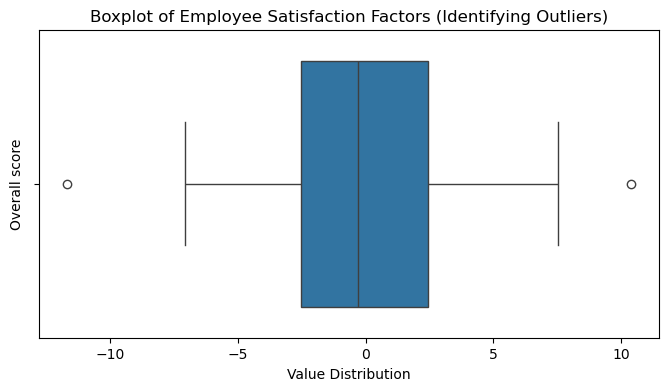

In [1760]:
# Identify the threshold for outliers in 'overall_score'
upper_threshold = 25  # Removing only the extreme high outlier

# Filter the dataset to remove the specific outlier
employee_data = employee_data[employee_data["overall_score"] < upper_threshold]

# Display outlier summary for overall score after filtering
# Boxplot visualization for outlier detection
plt.figure(figsize=(8, 4))
sns.boxplot(data=employee_data['overall_score'], orient="h")
plt.title("Boxplot of Employee Satisfaction Factors (Identifying Outliers)")
plt.xlabel("Value Distribution")
plt.ylabel("Overall score")
plt.show()



As result the extreme outlier valued over 25 was ignored.

### Inspect that data is normal after removing outlier


In [1762]:
# Import necessary libraries
import scipy.stats as stats

# Compute skewness and kurtosis for each factor
skew_kurt_values = []
for col in factor_columns:
    skewness = stats.skew(employee_data[col])
    kurtosis = stats.kurtosis(employee_data[col])
    skew_kurt_values.append({"Factor": col, "Skewness": skewness, "Kurtosis": kurtosis})

# Convert results into a DataFrame
skew_kurt_df = pd.DataFrame(skew_kurt_values)
print(skew_kurt_df)


           Factor  Skewness  Kurtosis
0        involved -0.733566  1.033975
1        autonomy -0.410434  0.221413
2    direct_manag -0.444238 -0.207975
3      integrated -0.312484  0.200613
4         welfare -0.507356  0.398752
5        training -0.321863  1.586587
6      work_press -0.836930  2.568293
7       reflexive  0.447044 -0.187168
8      innovative -0.247113 -0.628363
9       customers  0.052427 -0.171162
10  overall_score -0.032351  0.353490


## No Skew or Kurtosis detected

### **3.2.Construct data**

#### **3.2.1.Rename the columns/ drop unecessary columns**

Rename the columns (for better readibility) and remove any unnecessary ones. Follow these steps:

Apply the `rename()` method to the employee_data DataFrame.

Inside the method, pass a dictionary where the keys represent the current column names and the values represent the new names.

Include the `inplace=True` parameter to apply the changes directly to the DataFrame.

Use the` drop()` method to remove unwanted columns by assigning it to a new variable.

Specify the columns to be dropped as `['Id', 'agree']` and set axis=1 to indicate column-wise deletion.(Id and Agree columns are not needed at this stage)

Generate descriptive statistics using the `describe()` method to inspect the changes.



In [1764]:
# Rename columns.
employee_data.rename(columns = {'workloc':'Work_location','workleng':'Work_length', 
                                'autonomy':'Autonomy','intent_quit':'Intention_to_quit',
                                'sentiment':'Sentiment','manag_resp':'Managerial_responsibility',
                                'overall_score':'Overall_score'},
            inplace=True)


In [1766]:
# Delete unnecessary columns.
employee_data = employee_data.drop(['id', 'agree'], axis=1)
employee_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 141 entries, 1 to 141
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   Work_location              141 non-null    category
 1   Work_length                141 non-null    category
 2   Managerial_responsibility  141 non-null    category
 3   involved                   141 non-null    float64 
 4   Autonomy                   141 non-null    float64 
 5   direct_manag               141 non-null    float64 
 6   integrated                 141 non-null    float64 
 7   welfare                    141 non-null    float64 
 8   training                   141 non-null    float64 
 9   work_press                 141 non-null    float64 
 10  reflexive                  141 non-null    float64 
 11  innovative                 141 non-null    float64 
 12  customers                  141 non-null    float64 
 13  Overall_score              141 non-null 


### **3.3.Integrate and Formating** : **This step has already been performed to the data above, to let us inspect the correlation between variables**
***But if there is going to be any extra modeling its going to happen at this step.**

**I leave a copy of the transform below just for the refrence of what happened.(The code is written as comment to ignore errors due to the previous change to the data)**

Why Convert Categorical Variables to Numerical Representations?

Prepares Data for Analysis & Modeling – Many machine learning models and statistical techniques require numerical inputs.

Improves Consistency – Standardizes categorical responses for easy interpretation.

Avoids Errors – Ensures categorical columns are correctly typed to prevent processing issues.

Follow the Step-by-Step Instructions:

Convert Binary Categories to Numeric Values: Use `map()` to transform `"Yes" : 1` and `"No" : 0` in the agree column.

Define Categorical Columns: Identify columns (`workloc, workleng, manag_resp, intent_quit, sentiment`) that should be categorical.

Change Data Type to `'Category'`: Use .astype('category') to ensure correct data type, preventing errors.

Verify Changes: Use `info()` to confirm data types and check for missing values.

This ensures structured, clean, and machine-learning-ready data

In [1769]:
# Convert categorical variables to numerical representations

# Mapping 'agree' column (Yes = 1, No = 0)
#At this stage we dont use the agree columns and will leave it as a comment in the code to prevent getting any erros due to dropping it in previous step
#employee_data['agree'] = employee_data['agree'].map({'Yes': 1, 'No': 0})  

# Ensure categorical columns are correctly typed
#categorical_columns = ['workloc', 'workleng', 'manag_resp', 'intent_quit', 'sentiment']  # previously received an typo error for these columns hence changing their types to thier correct one which is category 
#employee_data[categorical_columns] = employee_data[categorical_columns].astype('category')



# Display cleaned data info and missing values
#employee_data.info()


## **4.Modeling:**

### **4.1.Hypothesis Testing**



 - Test whether work location (remote vs office) significantly affects overall satisfaction score.

 - Test whether intent to quit is significantly related to overall satisfaction score.

 - Compare remote vs office-based workers to see if there is a significant difference in intent to quit.



#### Hypothesis 1:

For all Hypothesis consider:

CI = 95%

a (level of sifnificance) = 0.05



**Null Hypothesis (H₀)**: There is no significant difference in overall satisfaction scores between remote and office-based employees.

**Alternative Hypothesis (H₁)**: There is a significant difference in overall satisfaction scores between remote and office-based employees.








#### Collecting Data:

Conduct the Power Analysis ,this helps validate if your data can support reliable conclusions.
Using Cohen's d medium effect size

**Follow Step-by-Step Instructions:**

Import Power Analysis Tool: Load `TTestIndPower` from `statsmodels.stats.power` to perform a power analysis.

Define Power Analysis Parameters: Effect Size (effect_size = `0.5`): Specifies the magnitude of difference (Cohen’s d).

Significance Level (alpha = 0.05): Sets the probability of rejecting a true null hypothesis.

Power (power = 0.8): Determines the probability of detecting an effect if one exists.

Initialize Power Analysis : Create an instance of `TTestIndPower()`.

Compute Required Sample Size : Use `.solve_power()` to calculate the sample size needed for statistical significance.

Display the Sample Size : Outputs the minimum required sample size for valid results.

In [1777]:
from statsmodels.stats.power import TTestIndPower


# Define power analysis parameters
effect_size = 0.5  # Medium effect size (Cohen's d)
alpha = 0.05  # Significance level
power = 0.8  # Desired statistical power

# Perform power analysis to calculate required sample size
power_analysis = TTestIndPower()
sample_size = power_analysis.solve_power(effect_size=effect_size, alpha=alpha, power=power, alternative='two-sided')

sample_size


63.7656117754095

The power analysis suggests that for an A/B test with a medium effect size (`Cohen's d = 0.5`), a significance level of `0.05`, and `80%` power, we need approximately:

`64` participants per group (rounded up from 63.77),Since we have `142` data points, we have sufficient data to conduct the A/B test.

#### Reject H0 or not:

Before choosing a test, you need to determine if the data is normally distributed. In previous steps using visualizationa and skewness and kurtosis, data disribution has been inspected already.

Which Statistical Test to Use?

If data is normal : Use **t-test** (parametric test).

**chose t-test to use here for  n>30 .**

A/B testing is used when you want to compare two groups and check if there is a significant difference between them.




**Follow Step-by-Step Instructions:**

Import Required Library : Load `ttest_ind` from `scipy.stats` to perform an independent t-test.

Split the Data into Two Groups:

Extract Overall_score for employees in `remote` work (`Work_location = 1`).
Extract Overall_score for employees in `office` work (`Work_location = 2`).

Perform Independent t-Test:

Compare the means of the two groups using `ttest_ind()`.
Set `equal_var=False` to account for unequal variances.

Store Test Results:

Capture the `t-statistic` and `p-value` from the t-test.

Display the Results: Output the t-statistic (difference measure) and p-value (significance test).

In [1784]:
#Import necessary libraries
from scipy.stats import ttest_ind

# Split the data into remote and office groups
remote = employee_data[employee_data["Work_location"] == 1]["Overall_score"]
office = employee_data[employee_data["Work_location"] == 2]["Overall_score"]

# Perform an independent t-test
t_stat, p_value = ttest_ind(remote, office, equal_var=False)

# Display results
t_stat, p_value


(-0.5264906730898783, 0.5998001115945165)



**Results:**

t-statistic = -0.526
                  
p-value = 0.599

Since the p-value `(0.599)` is greater than `0.05`, we fail to reject the null hypothesis. This means **there is no statistically significant difference in overall satisfaction scores between remote and office-based employees**.

But this does not mean there is no relationship, just that the test did not find enough evidence.

#### Hypothesis 2:


**Null Hypothesis (H₀):**  Employees who intend to quit have similar satisfaction scores as those who do not.

**Alternative Hypothesis (H₁):** Employees who intend to quit have significantly different satisfaction scores.

**Follow Step-by-Step Instructions:**

Import Required Library:

Load `f_oneway` from `scipy.stats` for ANOVA (if needed).

Load `ttest_ind` for an independent t-test.

Split Data into Groups:

Extract Overall_score for employees who intend to quit (`Intention_to_quit = 1`).

Extract Overall_score for employees who do not intend to quit (`Intention_to_quit = 2`).

(Optional) Extract data for "Not Sure" (Intention_to_quit = 3) for ANOVA testing.

Perform an Independent t-Test:

Compare the means of `"Yes"` vs. `"No"` groups using `ttest_ind()`.

Set `equal_var=False` to account for unequal variances.

Store Test Results:

Capture the `t-statistic` (measuring group difference).

Capture the `p-value` (determining statistical significance).

Display the Results:

Print the t-statistic and p-value to interpret significance

In [1787]:
# Perform A\B test to compare means across groups
from scipy.stats import f_oneway

# Split the data into groups based on intent to quit (Yes = 1, No = 2, Not sure = 3)
intent_yes = employee_data[employee_data["Intention_to_quit"] == 1]["Overall_score"]
intent_no = employee_data[employee_data["Intention_to_quit"] == 2]["Overall_score"]
#intent_unsure = employee_data[employee_data["Intention_to_quit"] == 3]["Overall_score"] #Could use ANOVA testing for all three 

# Perform an independent t-test
t_stat2, p_value = ttest_ind (intent_yes, intent_no, equal_var=False) #intent_unsure

# Display results
t_stat2, p_value


(0.5181031582494507, 0.6053587703111439)


**Results:**

t-statistic = 0.518

p-value = 0.605

Since the p-value `(0.605)` is much greater than`0.05`, we fail to reject the null hypothesis. This suggests that **overall satisfaction scores do not significantly differ among employees based on their intent to quit**.

#### Hypothesis 3:

**Null Hypothesis (H₀):** There is no significant difference in intent to quit between remote and office-based employees.

**Alternative Hypothesis (H₁):** There is a significant difference in intent to quit between remote and office-based employees.


**Chi-square tests are used for categorical data analysis, mainly when we want to determine if there is a statistical association between two categorical variables.**

**Follow Step-by-Step Instructions:**
    
Import Required Libraries

Load `numpy` for numerical operations.

Load `chi2_contingency` from `scipy.stats` for the Chi-square test.

Create a Contingency Table:

Use` pd.crosstab()` to generate a table comparing Work Location and Intention to Quit.

Perform the Chi-square Test:

Apply `chi2_contingency()` to test if there is an association between the two categorical variables.

Extract and Store Results:


Chi-square statistic `(chi2_stat)`: Measures the difference between observed and expected values.

p-value `(p_value_chi2)`: Determines statistical significance.

Degrees of freedom `(dof)`: Represents the number of independent comparisons.

Expected values `(expected)`: Shows the theoretical distribution under independence.

Display the Results:

Print the Chi-square statistic and p-value to interpret significance

In [1791]:
import numpy as np
from scipy.stats import chi2_contingency

# Create a contingency table for work location and intent to quit
contingency_table = pd.crosstab(employee_data["Work_location"], employee_data["Intention_to_quit"])

# Perform Chi-square test
chi2_stat, p_value_chi2, dof, expected = chi2_contingency(contingency_table)

# Display results
chi2_stat, p_value_chi2


(1.8357480252451075, 0.3993671887917354)



**Results:**

Chi-square statistic = 1.83

p-value = 0.399

Since the p-value `(0.399)` is greater than `0.05`, we fail to reject the null hypothesis. This means **there is no statistically significant difference in intent to quit between remote and office-based employees**.




#### Hypothesis 4:

**H₀:** Employees with management responsibilities do not have significantly different satisfaction scores compared to non-managers.

**H₁:** Employees with management responsibilities have significantly different satisfaction scores.

**Follow Step-by-Step Instructions:**

Split Data into Groups:

Extract Overall_score for managers (`Managerial_responsibility = 1`).

Extract Overall_score for non-managers (`Managerial_responsibility = 2`).

Perform an Independent t-Test:

Use `ttest_ind()` to compare the mean Overall Score between the two groups.

Set `equal_var=False` to account for unequal variances in the two groups.

Store Test Results:

t-statistic `(t_stat4)`: Measures the difference between means.

p-value `(p_val4)`: Determines statistical significance.

Display the Results:

Print the t-statistic and p-value to conclude the hypothesis test

In [1796]:
# Hypothesis : Difference in satisfaction between managers and non-managers
manager_scores = employee_data[employee_data['Managerial_responsibility'] == 1]['Overall_score']
non_manager_scores = employee_data[employee_data['Managerial_responsibility'] == 2]['Overall_score']

# Perform an independent t-test
t_stat4, p_val4 = ttest_ind(manager_scores, non_manager_scores, equal_var=False)

# Display results
t_stat4, p_val4

(-0.9775663091037639, 0.33189896309095523)

**Results:**

t_statistic = -0.977

p-value = 0.331

Since the p-value `(0.331)` is greater than `0.05`, we fail to reject the null hypothesis. This means **Employees with management responsibilities do not have significantly different satisfaction scores compared to non-managers.**.


#### **A/B testing does not show significant results, you can explore further relationships using regression.**

### **4.2.Simple and Multiple Linear Regression Models**

 - Create a Simple Linear Regression Model using the most correlated feature (autonomy).

### 4.2.1.Import data and perform EDA: This step has been already performed previously.

### 4.2.2.Specify the variables and model  


Import the `sklearn` and `statsmodels.api` libraries.

Use the `sm` alias for `statsmodels.api`.

Import the `LinearRegression` module `from sklearn.linear_model`.

Create a new variable `X` to specify the independent variable.

Specify the column as data `Autonomy`.

Create a new variable `y` to specify the dependent variable.

Specify the column as data `Overall_score`.

Add the values.reshape(-1, 1) method. To ensure the data is 2D (array consisting of various rows and columns), you’ll need to use the NumPy `values.reshape()` method. Not reshaping the variables, or using a 1D array, would result in a ValueError when running a linear regression model.

Repeat the steps for the independent variable.

Create a new variable  `lm` to store the LinearRegression() method.

Specify the `fit()` method and the variables.

In [1801]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Define independent (X) and dependent (y) variables for simple regression
# Independent (X)
X = employee_data['Autonomy'].values.reshape(-1, 1) 
# Dependent (y)
y = employee_data['Overall_score'].values.reshape(-1, 1) 

# Specify the model.
lm = LinearRegression()

# Fit the model.
lm.fit(X, y) 

LinearRegression()

### **4.2.3.Split the data** 

Import the `train_test_split` module from `sklearn.model_selection`.

Create the variables `x_train, x_test, y_train, y_test` to store the split of the data set based on the variables into train and test subsets.

Use the `train_test_split()` method to split the data.

Inside the bracket, specify the variables as `x` and `y`, train_size as `70%` (`0.7`), and the random_state as 64.

In [1804]:
# Import the sklearn module.
from sklearn.model_selection import train_test_split 

# Create  the subset (70/100); 
# Control the shuffling/avoid variation in values between variable.
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    train_size=0.7,
                                                    random_state=42)

### **4.2.4.Predict the training set values**  

Predict the values in the training data set `(x_train)` using the `y_pred` function. 

Create a new variable `y_pred` to store the `lm.predict()` method. 


Specify the data as `x_train`.

View the output with `y_pred`.



In [1807]:
# Predict the training set values.
y_pred = lm.predict(X_train) 

# View the output
y_pred

array([[-1.0741474 ],
       [ 1.0562799 ],
       [-1.0741474 ],
       [-0.00893375],
       [ 1.0562799 ],
       [-1.0741474 ],
       [ 1.0562799 ],
       [-1.0741474 ],
       [ 1.0562799 ],
       [ 1.0562799 ],
       [ 2.12149355],
       [-1.0741474 ],
       [-2.13936105],
       [-0.00893375],
       [-2.13936105],
       [-1.0741474 ],
       [ 1.0562799 ],
       [ 1.0562799 ],
       [-2.13936105],
       [-3.2045747 ],
       [-0.00893375],
       [ 2.12149355],
       [-1.0741474 ],
       [-1.0741474 ],
       [-0.00893375],
       [-0.00893375],
       [ 1.0562799 ],
       [-3.2045747 ],
       [-2.13936105],
       [-3.2045747 ],
       [ 1.0562799 ],
       [-3.2045747 ],
       [-0.00893375],
       [ 1.0562799 ],
       [-1.0741474 ],
       [-0.00893375],
       [ 1.0562799 ],
       [-3.2045747 ],
       [ 1.0562799 ],
       [-2.13936105],
       [-0.00893375],
       [-0.00893375],
       [ 1.0562799 ],
       [-3.2045747 ],
       [-2.13936105],
       [-0

### **4.2.5.Create a visualisation**   


Import Required Libraries:

Load `matplotlib.pyplot` for plotting.

Load `numpy` for numerical operations.

Create a Scatter Plot of Actual Data:

Plot `X_train` (Autonomy) on the x-axis.

Plot `y_train` (Overall Score) on the y-axis.

Use blue dots to represent actual data points.

Plot the Regression Line:

Use `plt.plot()` to draw the predicted regression line (y_pred) in red.

Set linewidth=2 for better visibility.

Add Labels and Title:

Label the x-axis as `"Autonomy"`.

Label the y-axis as `"Overall Score"`.

Add a title: "Simple Linear Regression: Autonomy vs Overall Score".

Add a Legend:

Indicate actual data and regression line in the legend.

Display the Plot:

Use `plt.show()` to render the visualization

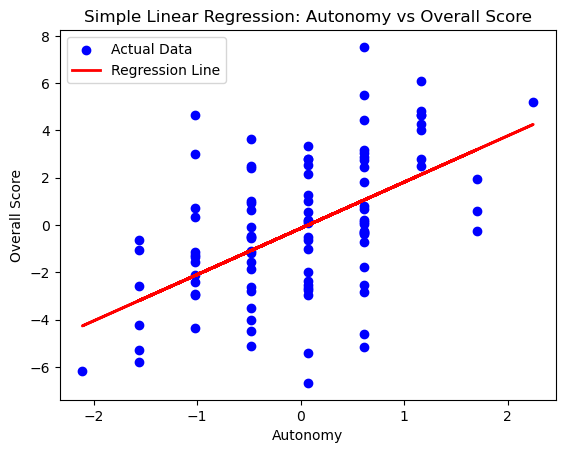

In [1810]:
#Import necessary libraries
import matplotlib.pyplot as plt
import numpy as np

# Scatter plot of actual data points
plt.scatter(X_train, y_train, color='blue', label='Actual Data')

# Regression line
plt.plot(X_train, y_pred, color='red', linewidth=2, label='Regression Line')

# Labels and title
plt.xlabel('Autonomy')
plt.ylabel('Overall Score')
plt.title('Simple Linear Regression: Autonomy vs Overall Score')
plt.legend()

# Show the plot
plt.show()


### **4.2.6.Determine the accuracy of the model**   


Test the accuracy of the model based on the training data using intercept, coefficient, `R2`, `MAE`, `MSE`, and `RMSE`.

Import the `math` and metrics modules. The `metrics` module is part of the `sklearn` library.

Use the `print()` function to print the values with a docstring to separate values. For example, `print("R-squared value: ")`. Use the following parameters and methods:

𝑅2: add the `lm.score()` method and specify the x_train and y_train data sets.

intercept: `lm.intercept_`

coefficient: `lm.coef_`

MAE:` metrics.mean_absolute_error()`

MSE: `metrics.mean_squared_error()` ( Set the parameter squared=False.)

RMSE: `math.sqrt(metrics.mean_squared_error())`

In [1813]:
# Accuracy of train data set.
# Import metrics module.
import math
from sklearn import metrics

# Print R-squared value of the test data.
print("R-squared value: ", lm.score(X_train,
                                    y_train)) 

# Print the intercept value.
print("Intercept value: ", lm.intercept_) 

# Print the coefficient value.
print("Coefficient value: ", lm.coef_)

# Print the MAE.  
print('Mean Absolute Error (Final):', metrics.mean_absolute_error(X_train,
                                                                  y_pred))  

# Print the MSE. 
print('Mean Square Error (Final):', metrics.mean_squared_error(y_train,
                                                               y_pred,
                                                               squared=False)) 

# Print the RMSE. 
rmse = math.sqrt(metrics.mean_squared_error(X_train,
                                            y_pred))

print('Root Mean Square Error (Final):', rmse)

R-squared value:  0.2570382675790871
Intercept value:  [-0.14396083]
Coefficient value:  [[1.95660023]]
Mean Absolute Error (Final): 0.6636991174798442
Mean Square Error (Final): 2.604487454444853
Root Mean Square Error (Final): 0.8279460764405248


**R-squared value (R²):** 0.257

Meaning: R² represents the proportion of variance in the dependent variable (Overall Score) explained by the independent variable (Autonomy).

Interpretation: An R² value of 0.257 means that only 25.7% of the variation in Overall_score is explained by Autonomy. This suggests that while Autonomy has some effect on Overall_score, other factors (not included in the model) might play a more significant role.

**Intercept (β₀):** -0.14396
 
Meaning: The intercept is the predicted Overall_score when Autonomy is zero.

Interpretation: If Autonomy were 0, the model predicts an Overall_score of -0.14396. This value may not be meaningful in practice if Autonomy = 0 is not a realistic scenario.

**Coefficient (β₁):** 1.9566
 
Meaning: The coefficient represents the change in Overall_score for each 1-unit increase in Autonomy.

Interpretation: If Autonomy increases by 1 unit, the Overall_score is expected to increase by 1.96 units. This suggests that greater autonomy is associated with higher overall scores.

**Mean Absolute Error (MAE):** 0.664
 
Meaning: The average absolute difference between the actual and predicted values.

Interpretation: On average, the model’s predictions deviate from the actual values by 0.664 points in Overall_score.

**Mean Squared Error (MSE):** 2.604

Meaning: The average squared difference between actual and predicted values.

Interpretation: Higher MSE values indicate larger errors. Since MSE squares the differences, larger errors are penalized more.

 **Root Mean Squared Error (RMSE):** 0.828
   
Meaning: RMSE is the square root of MSE, giving an error measurement in the same unit as the dependent variable.

Interpretation: The model’s average prediction error is 0.828 points in Overall_score.

**Insights:**
Your model explains only `25.7%` of the variance in Overall_score, which suggests that other variables should be considered for better prediction.
The coefficient indicates that higher autonomy is associated with higher scores.

The prediction errors (MAE, MSE, RMSE) suggest that the model's predictions are not very precise.

To improve the model, considering add more relevant features (e.g.,` work presure`, `direct manager` , `welfare` )


### **4.2.7.Evaluate the model**  

Import Required Libraries:

Load `matplotlib.pyplot` for visualization.

Load `numpy` for numerical operations.

Predict Test Set Values:

Use the trained linear regression model `(lm`) to predict` y_pred_test` from `X_test`.

Create a Scatter Plot for Actual Data:

Plot `X_test` (Autonomy) on the x-axis.

Plot `y_test` (Overall Score) on the y-axis.

Use blue dots to represent actual test data points.

Plot the Regression Line:

Use `plt.plot()` to draw the predicted regression line `(y_pred_test)` in red.

Set `linewidth=2` for better visibility.

Add Labels and Title:

Label the `x-axis` as "Autonomy".

Label the `y-axis` as "Overall Score".

Add a title: "Simple Linear Regression: `Autonomy vs Overall Score`".

Add a Legend:


Differentiate between actual data and predicted regression line using plt.legend().

Display the Plot:

Use `plt.show()` to render the visualization

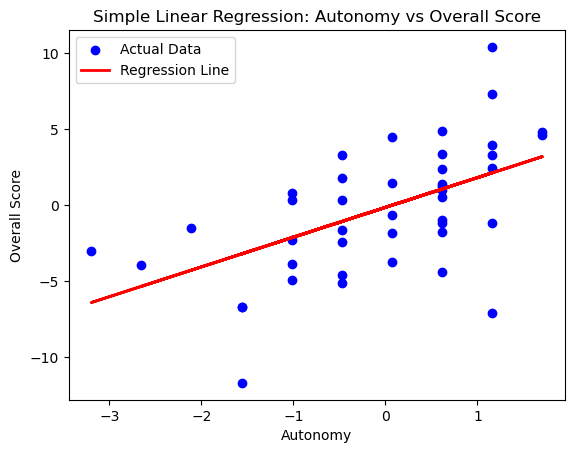

In [1817]:
#Import necessary libraries
import matplotlib.pyplot as plt
import numpy as np

# Predict the test set values.
y_pred_test = lm.predict(X_test)

# Scatter plot of actual data points
plt.scatter(X_test, y_test, color='blue', label='Actual Data')

# Regression line
plt.plot(X_test, y_pred_test, color='red', linewidth=2, label='Regression Line')

# Labels and title
plt.xlabel('Autonomy')
plt.ylabel('Overall Score')
plt.title('Simple Linear Regression: Autonomy vs Overall Score')
plt.legend()

# Show the plot
plt.show()


Calculate and Print R-Squared Value:

Use `lm.score(X_test, y_test)` to compute the R-squared `(R²)` value, which measures how well the model explains the variance in the data.

Print the Intercept Value:

`lm.intercept`_ displays the y-intercept of the regression equation.

Print the Coefficient Value:

`lm.coef`_ shows the slope (coefficients), indicating the impact of Autonomy on Overall Score.

Calculate and Print Mean Absolute Error (MAE):

`metrics.mean_absolute_error(y_test, y_pred_test)` computes the average absolute difference between actual and predicted values.

Calculate and Print Mean Squared Error (MSE):

`metrics.mean_squared_error(y_test, y_pred_test, squared=False)` calculates the average squared differences between actual and predicted values.

Calculate and Print Root Mean Square Error (RMSE):

Uses `math.sqrt()` to compute RMSE, which measures the standard deviation of prediction errors.

Display All Metrics:

Print `R², intercept, coefficients, MAE, MSE` and `RMSE` for final model evaluation.

In [1820]:
# Print R-squared value of the test data.
print("R-squared value: ", lm.score(X_test,
                                    y_test)) 

# Print the intercept value.
print("Intercept value: ", lm.intercept_) 

# Print the coefficient value.
print("Coefficient value: ", lm.coef_)

# Print the MAE.   
print('Mean Absolute Error (Final):', metrics.mean_absolute_error(X_test,
                                                                  y_pred_test))  

# Print the MSE. 
print('Mean Square Error (Final):', metrics.mean_squared_error(y_test,
                                                               y_pred_test,
                                                               squared=False))  

# Print the RMSE. 
rmse_2 = math.sqrt(metrics.mean_squared_error(X_test,
                                              y_pred_test))

print('Root Mean Square Error (Final):', rmse_2)

R-squared value:  0.3271845076704746
Intercept value:  [-0.14396083]
Coefficient value:  [[1.95660023]]
Mean Absolute Error (Final): 0.8774634315432882
Mean Square Error (Final): 3.4529484412823686
Root Mean Square Error (Final): 1.1003536637875047


**R-squared value (R²):** 0.327

Meaning: This indicates that `32.7%` of the variance in Overall_score is explained by Autonomy.

Interpretation: The model suggests that Autonomy has a moderate impact on Overall_score, but `67.3%` of the variation remains unexplained, meaning that other factors (e.g., `welfare`, `work pressure`, `training`) might be influencing the Overall_score significantly.

**Intercept (β₀):** -0.14396

Meaning: When Autonomy is zero, the predicted Overall_score is -0.14396.

Interpretation: If Autonomy = 0 is a meaningful scenario, it suggests that employees with no autonomy would have an` Overall_score` close to zero (or slightly negative), indicating very low job satisfaction or performance.

**Coefficient (β₁):** 1.9566

Meaning: For every 1-unit increase in Autonomy, the Overall_score increases by 1.9566 units.

Interpretation: Higher autonomy is strongly associated with better overall scores. Employees who feel more autonomous tend to rate their overall work experience higher.

**Mean Absolute Error (MAE):** 0.877

Meaning: On average, the absolute difference between actual and predicted Overall_score values is 0.877 points.

Interpretation: The model’s predictions are off by about 0.88 points on average in Overall_score.

**Mean Squared Error (MSE):** 3.453

Meaning: This is the average squared difference between actual and predicted values.

Interpretation: A higher MSE suggests that larger errors are occurring more frequently. Since it's squared, it amplifies the effect of larger deviations.

**Root Mean Squared Error (RMSE):** 1.100

Meaning: The average prediction error in the same unit as Overall_score.

Interpretation: The model’s typical error in predicting Overall_score is 1.1 points, which is fairly high considering the possible range of scores.

**Insights:**
Autonomy positively impacts overall scores (strong positive coefficient).
Model still lacks full predictive power (R² = `32.7%`, meaning other variables are important).
Errors indicate room for improvement (MAE = `0.88`, RMSE = `1.1`).

#### ***What to Do Next:**
Add more independent variables: Consider including `work pressure`, `training`, `integrated work culture`, or `sentiment scores` in a **multiple regression model**.

### **4.2.8.Make predictions**  

Use the `predict()` Method:

Apply the trained linear regression model `(lm)` to predict Overall Satisfaction based on given Autonomy values.
The input values ([[5], [3], [4], [-3.5], [0], [4.5]]) represent different levels of Autonomy.

Store the Predicted Results:

`predicted_satisfaction` holds the model’s predicted Overall Satisfaction scores for the given autonomy levels.

Print the Results:

Display the predicted values using.

Interpret the Predictions:

Each predicted value represents the expected Overall Satisfaction for a given Autonomy level.

In [1824]:
# Use the predict() method.
predicted_satisfaction = lm.predict([[5], [3], [4], [-3.5], [0], [4.5]])  

# Print the results.
print(f"Predicted Overall satisfaction By Autonomy :\n{predicted_satisfaction}")  

Predicted Overall satisfaction By Autonomy :
[[ 9.63904033]
 [ 5.72583986]
 [ 7.68244009]
 [-6.99206164]
 [-0.14396083]
 [ 8.66074021]]


**Simple Linear Regression Didn’t Show Strong Results**

Simple Linear Regression analyzes the impact of one independent variable `Autonomy` on the dependent variable `Overall Score`.

`R²` value is low, it means Autonomy alone doesn’t explain much of the variation in Overall Score.



**Need for Multiple Factors:**

Employee satisfaction is influenced by many factors, not just autonomy. Variables like training, work pressure, welfare, managerial support, and reflexive thinking may also impact Overall Score.

Multiple Linear Regression (MLR) allows us to include multiple independent variables, improving prediction accuracy.

Benefits of Moving to Multiple Linear Regression:

- Captures the combined effect of multiple factors.

- Reduces bias by including relevant predictors.

- Improves model accuracy by increasing R² value.

- Helps identify key drivers of Overall Score.

**Next Steps in Multiple Linear Regression**

Include additional independent variables like Training, Work_Pressure, Welfare, etc.

Re-run the regression model to check for better R² and significant p-values.

Interpret coefficients to see which factors strongly impact satisfaction.

**Conclusion**

Since Simple Linear Regression failed to explain Overall Score effectively, we upgraded to Multiple Linear Regression to capture the real-world complexity of employee satisfaction

## **5.Multiple linear regression model**(steps)

### **Step 1. Import and prepare the data**

**a) Import the data**

**b) Explore the data**

**c) Prepare the data**

   **1. Determine if there are missing values**            

   **2. Determine if there are duplicate rows**        
   
   **3.Inspect Data type and correct it to its propper version if needed**
  
   **4. Compute descriptive statistics**             

   **5. Compute the correlation between variables**

   **6. Visualise the correlation variables**                  

   ### **Note** : Above step 1 has been done to the data above in previous steps, thus will procced to the following steps.

### **Step 2: Determine multicollinearity**

**a) Create a pairplot**

**b) Set the variables**

**c) Compute the VIF**


### **Step 3: Specify the variables and model**

### **Step 4: Splitting the data**

**a) Split the data**

**b) Predict the training set values**

**c) Create a visualisation**

### **Step 5: Determine the accuracy of the model**

### **Step 6: Evaluate the model and make predictions**

**a) Evaluate the model**

**b) Make predictions**

### **Step 7: Share your findings**


##################################################################################################################################

### **Step 2: Determine multicollinearity**

#### **a) Create a pairplot**

Create a pairplot to view the spread of the data (histograms) and possible correlations (scatterplots).

**Reasons for Using Pair Plot in Our Analysis:** 

**1. Checking for Normal Distribution** 

**• How Pair Plot Helps:** 

o If the distribution appears symmetrical and bell-shaped, it suggests 
normality. 

o In ServiceFirst’s data, variables like Overall Score, Autonomy, and Training 
showed near-normal distributions, while Work Pressure and Sentiment 
were skewed. 

**2. Checking for Homoscedasticity (Equal Variance Assumption)** 

• Homoscedasticity means that the variance of residuals (errors) remains 
constant across all values of the independent variable. Unequal variance 
(heteroscedasticity) can lead to unreliable regression results. 

**• How Pair Plot Helps:** 

o A scatter plot matrix in pairplot() helps visualize how spread-out data 
points are across different independent variables. 

o In ServiceFirst’s data, scatter plots showed that some variables had 
varying spread (e.g., Work Pressure had increasing variance with Overall 
Score). 

o To address this, log transformations or standardization can be applied. 

**3. Checking for Linearity** 

•  Linear regression assumes a linear relationship between independent and 
dependent variables. If the relationship is nonlinear, the model will produce poor 
predictions. 

**• How Pair Plot Helps:** 

o In ServiceFirst’s dataset, variables like Autonomy and Training showed 
strong linear relationships with Overall Score, making them suitable for 
regression modeling. 

o However, variables like Sentiment and Intention to Quit showed nonlinear 
trends, suggesting they might be better suited for classification models 
instead of regression. 

**4. Checking for Independence of Variables** 

• Multiple linear regression assumes that independent variables are not highly 
correlated (to prevent multicollinearity). 

**• How Pair Plot Helps:** 

o pairplot() helps visualize correlations between variables through scatter 
plots and correlation patterns. 

o If two independent variables show a strong linear relationship, it might 
indicate multicollinearity, requiring one variable to be removed. 

o In our dataset, Work Pressure and Direct Management showed high 
correlation, which was later confirmed with Variance Inflation Factor (VIF) 
analysis.




Specify Seaborn as sns and the `pairplot()` function. 


Inside the brackets, specify the DataFrame as `employee_data`.



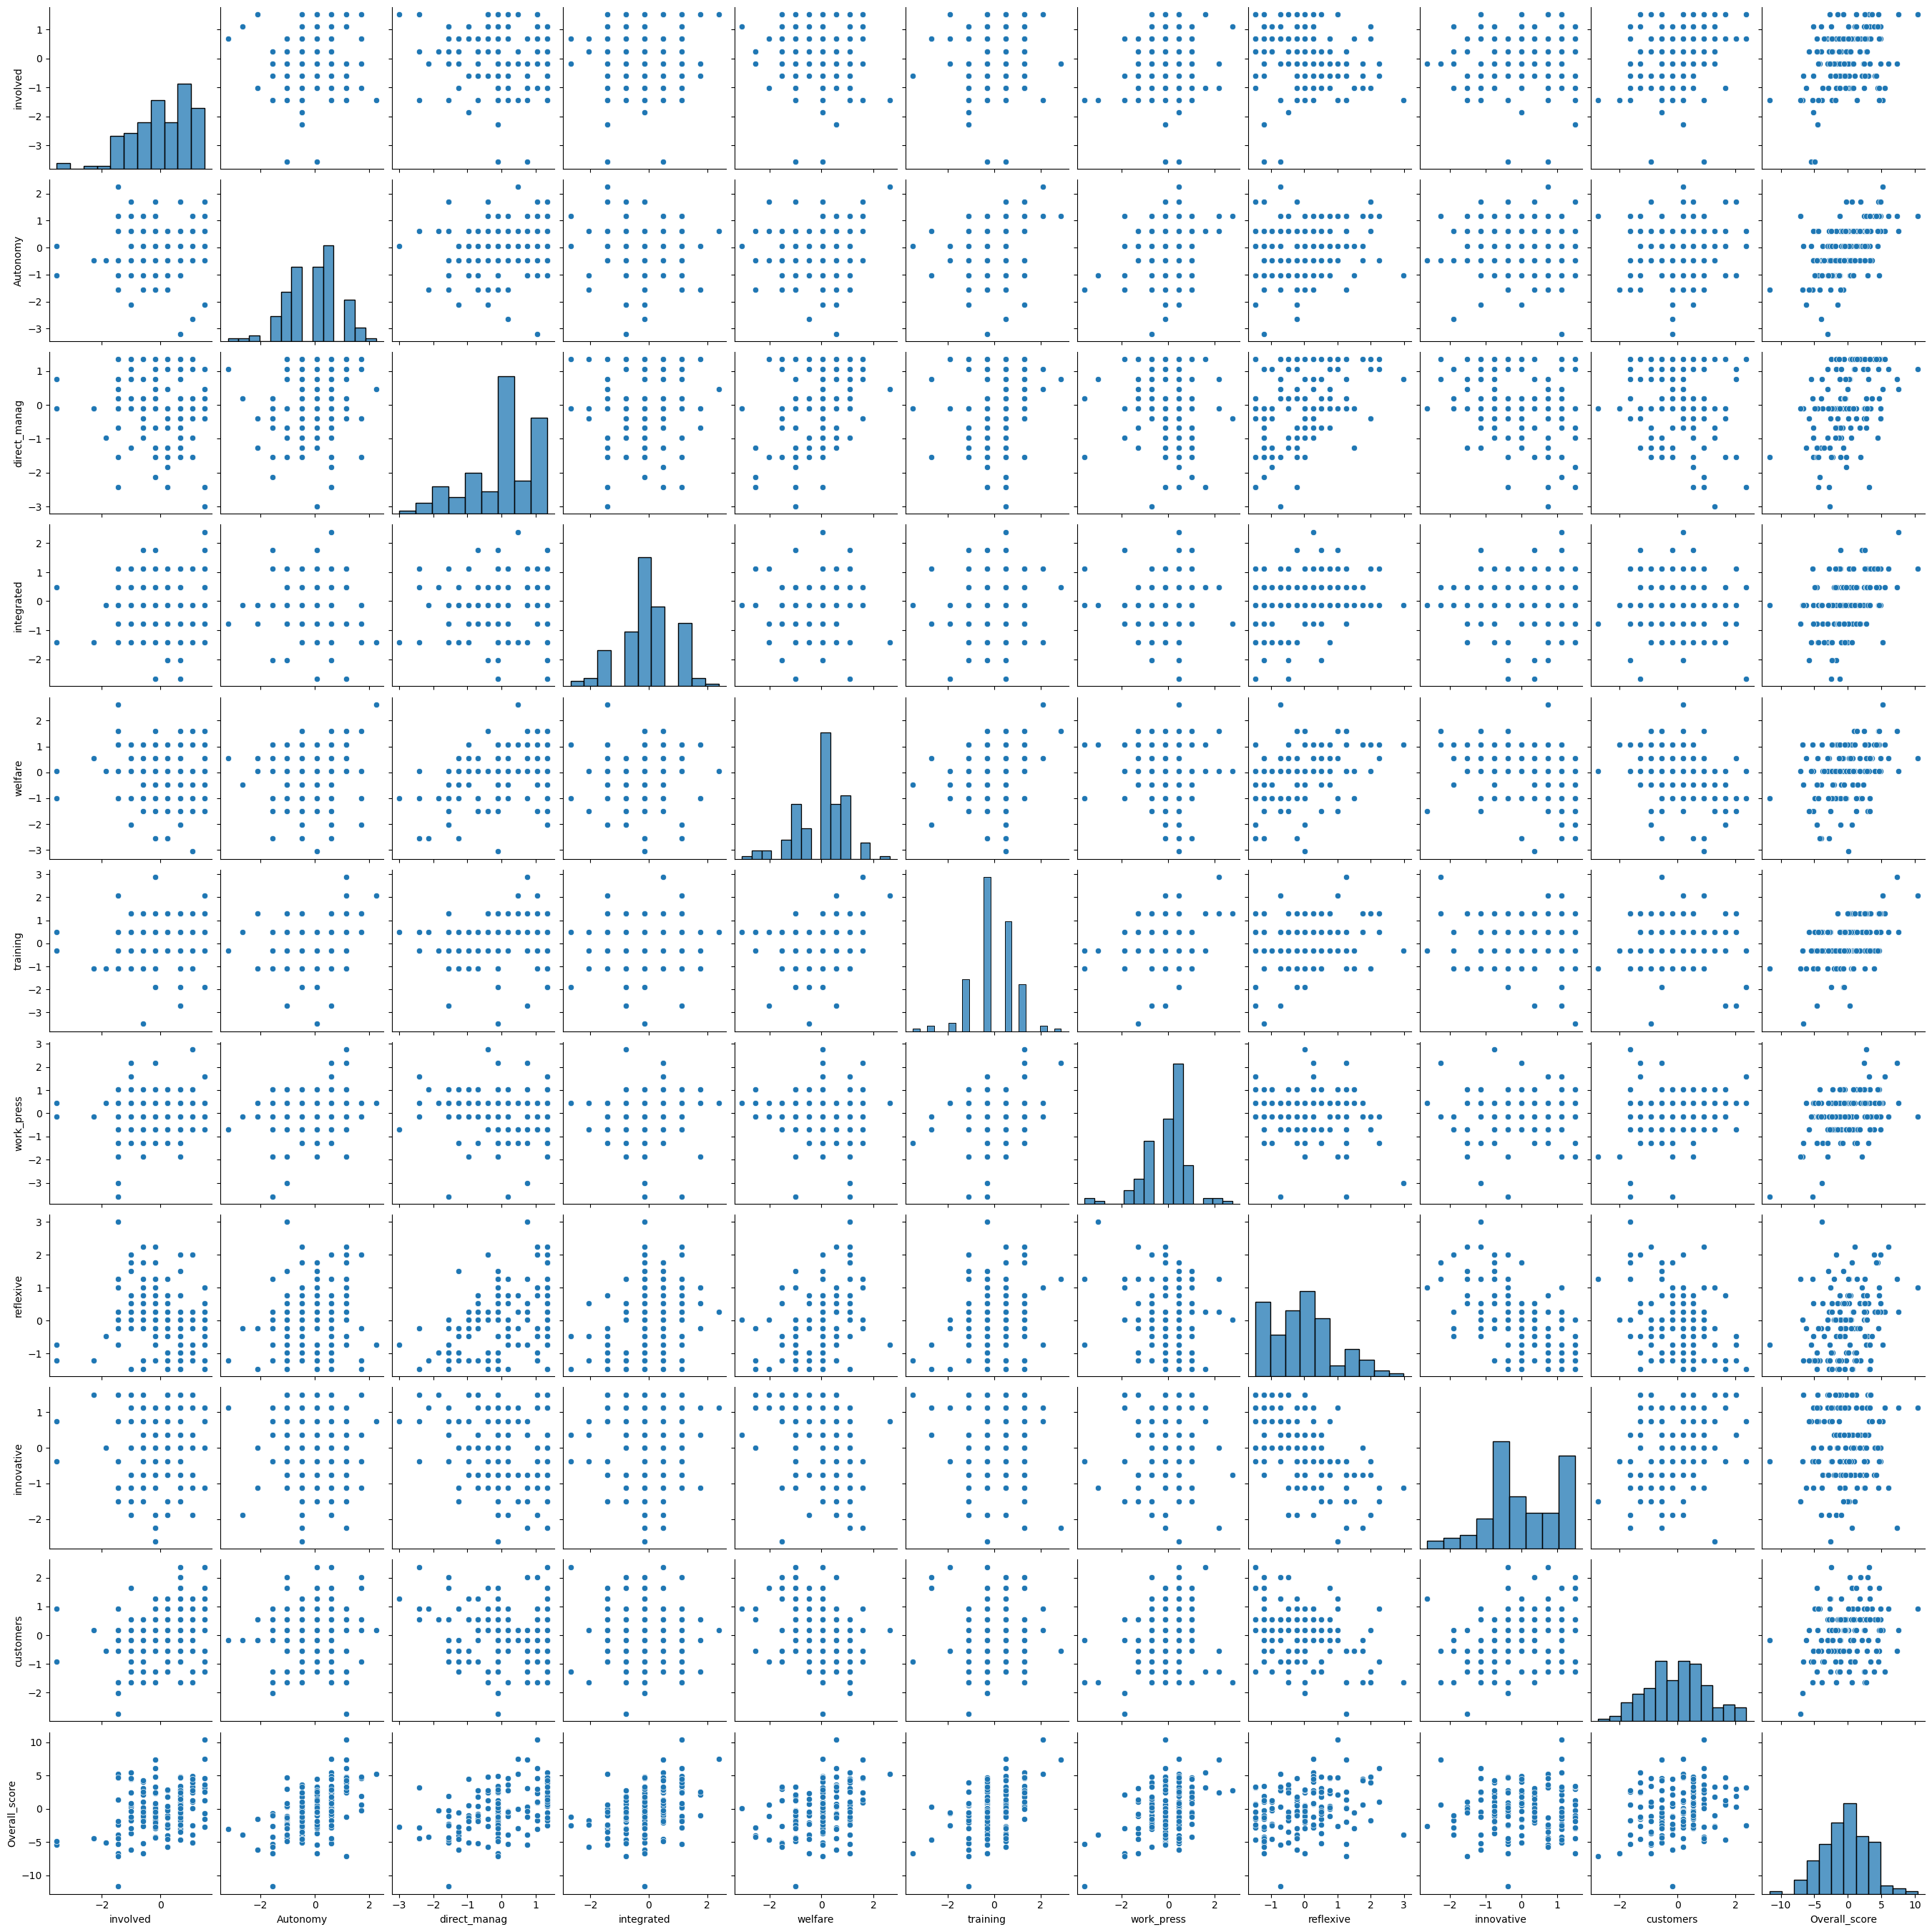

In [1830]:
# Visualisation:
# Create a pairplot.
sns.pairplot(employee_data)

pairplot() helps visually detect collinear variables.

Multicollinearity leads to unstable regression models and misleading results.

If found, consider removing one of the correlated variables or using VIF (Variance Inflation Factor)

Explore the `pairplot()` method more by specifying the hue as categorical data (e.g. Intention_to_quit). 

This can help for better comparession between the Variables.

Use `Intention_to_quit` as `hue` to do the camparession.

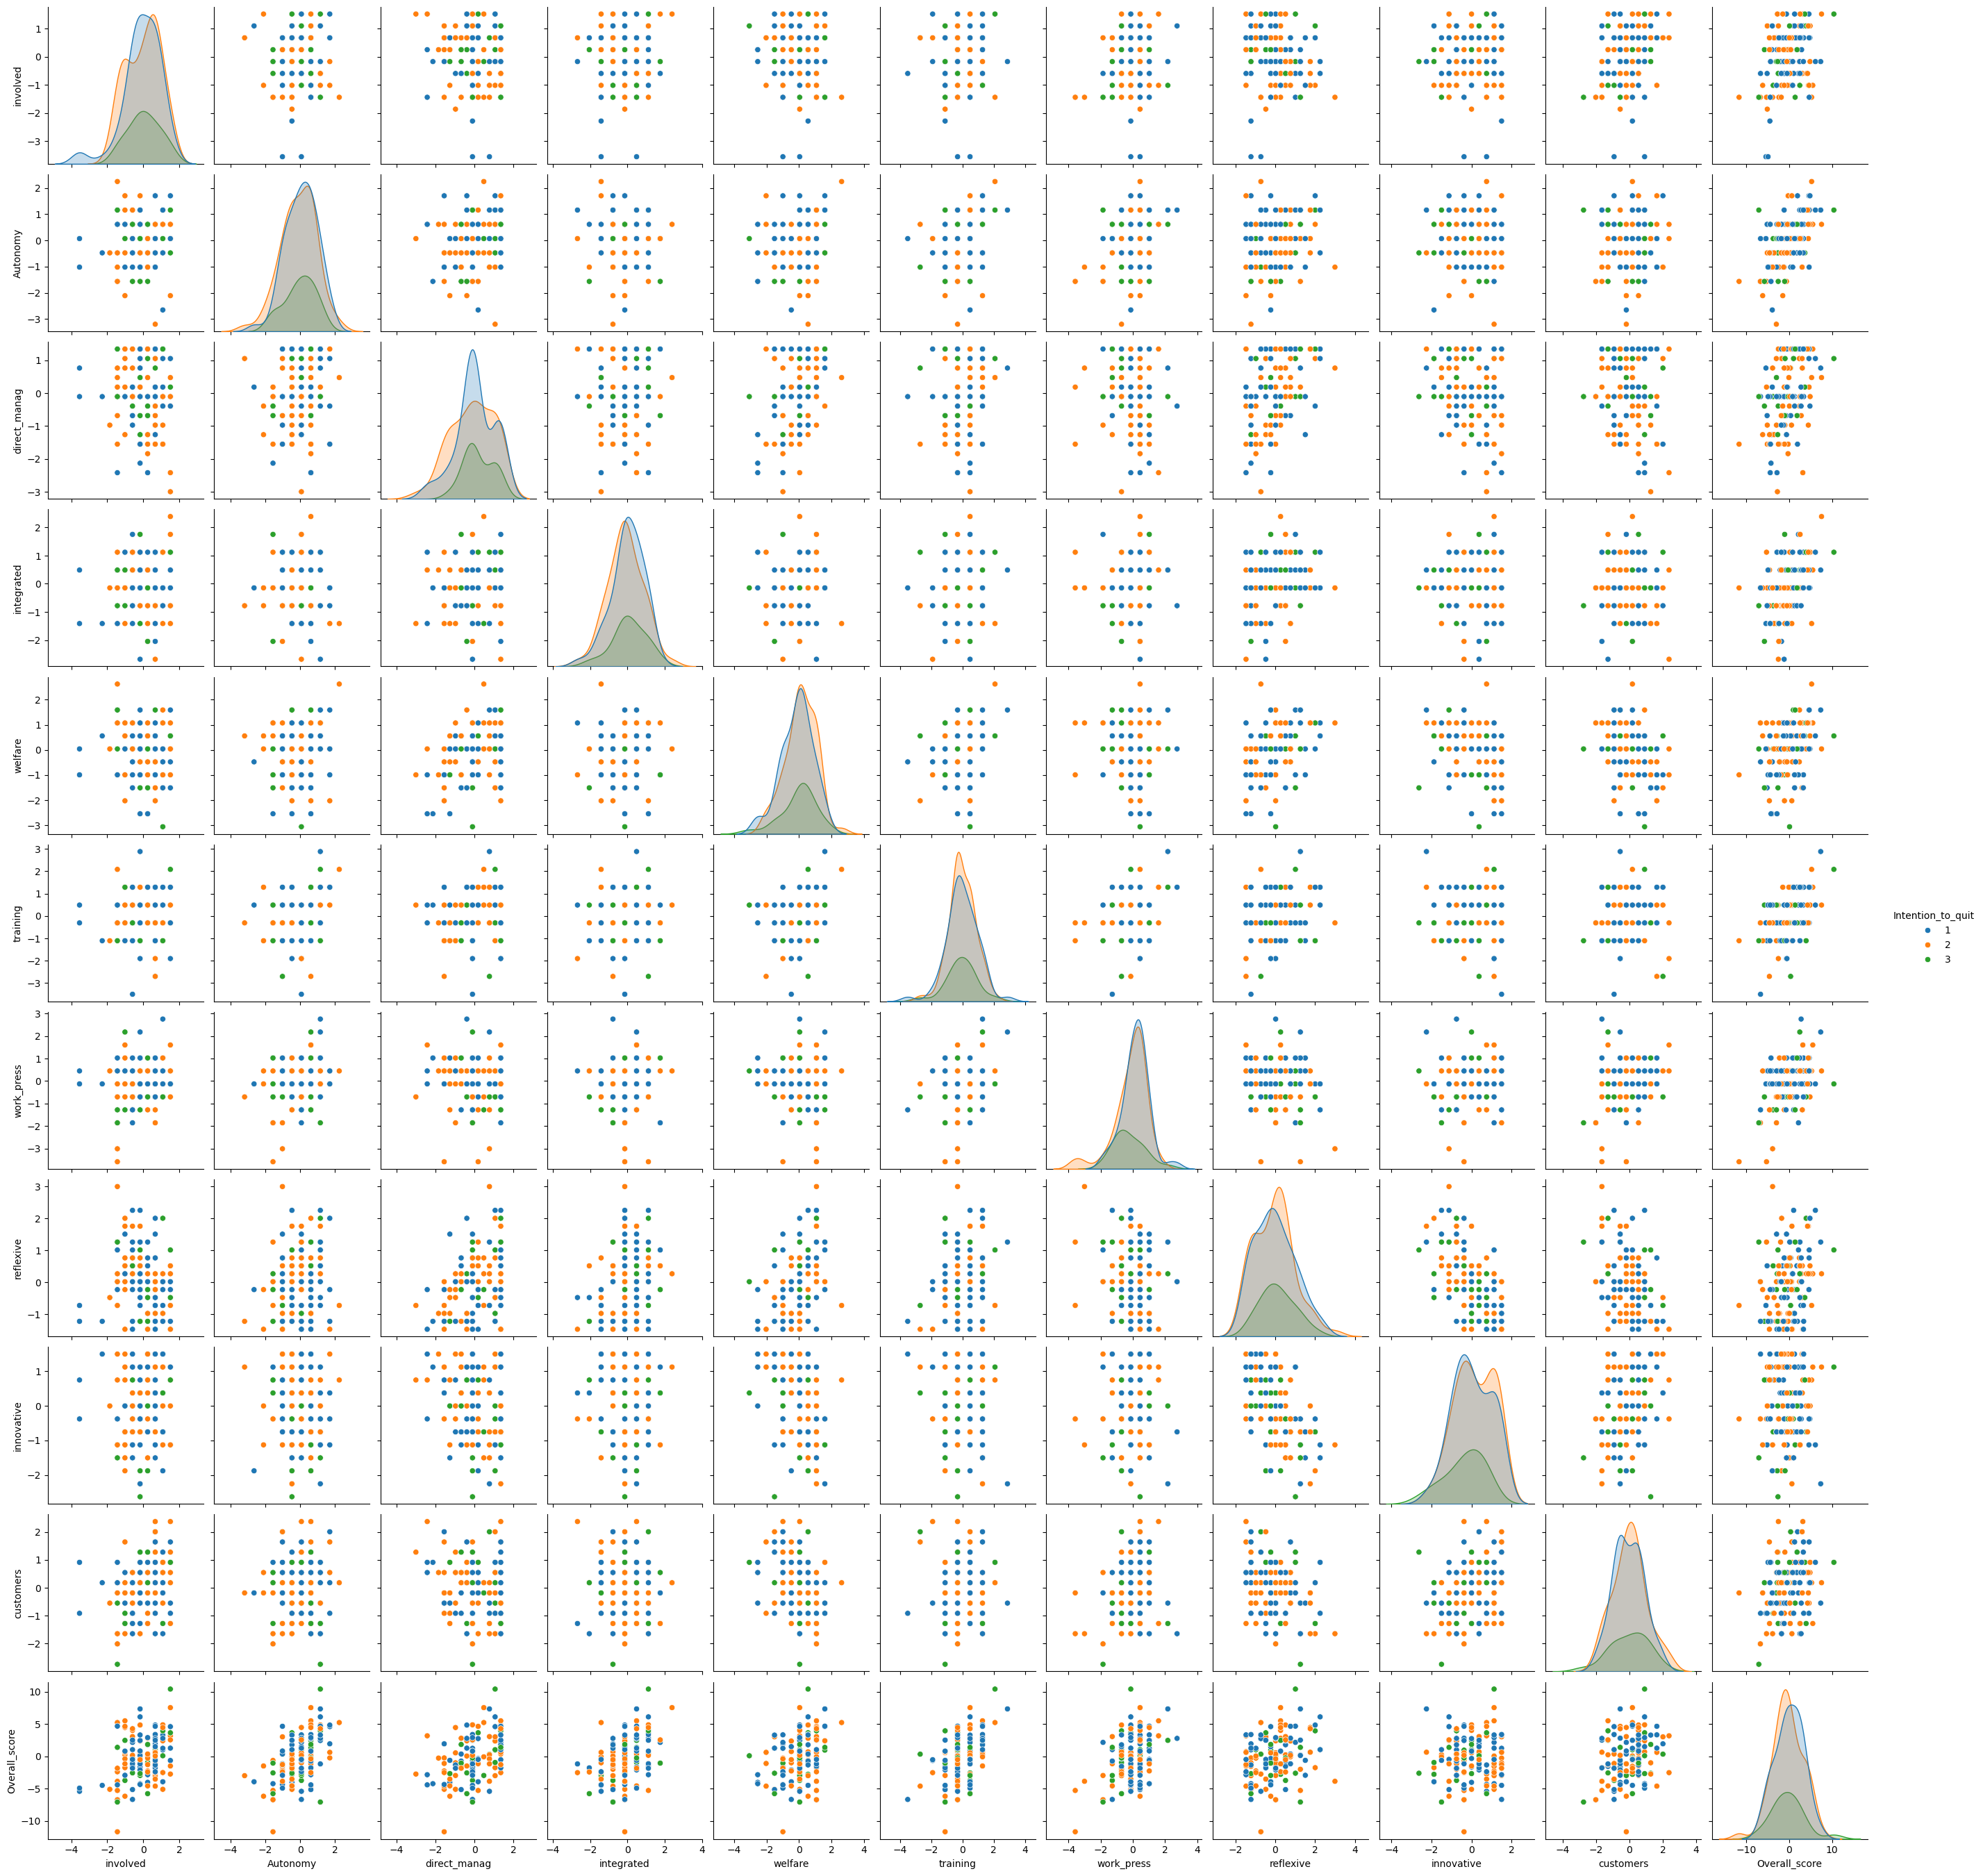

In [462]:
# Create a pairplot and use Intention_to_quit as hue
sns.pairplot(employee_data, hue = 'Intention_to_quit')


#### **b) Set the variables**


Set the variables. The variables will be based on the specific business question. In this case Is there a relationship between the Overall satisfaction score and other factors (e.g. the number of work location , welfare, autonomy, work length ...)? To answer the business question, Overall satisfaction score will be 𝑌 and 𝑋 will be the remaining columns.

Create a variable`X` to store the independent variables as all the columns except `Overall_score`. Use the drop() method.

Specify the DataFrame as employee_data.

Create a second variable `y` to store the dependent variable as cost.

View the output of both variables with the shape method.

In [1845]:
# Independent variable
X = employee_data.drop(columns = 'Overall_score')

# Dependent variable
y = employee_data['Overall_score']

# View the DataFrames.
print(y.shape)
print(X.shape)

(141,)
(141, 15)


#### **c) Compute the VIF**

Compute the variance inflation factor (VIF) to determine multicollinearity.

Import the `sklearn library` and the `statsmodels.api` as `sm`.

Also import the `variance_inflation_factor` model from `statsmodels.stats.outliers_influence` to compute the VIF values of each variable.

Create a new variable`vif_data` to store the Pandas `DataFrame()` method. This instructs Python to create a new DataFrame to store the `vif_data`.

Specify the `vif_data` DataFrame and the column `'feature'` and set it equal to `X.columns`. This indicates to Python that all the independent variables (stored as x) will be displayed as rows in the `vif_data` DataFrame. 

Calculate the `VIF` for each feature and add a new column to the DataFrame containing the  `VIF` values. Note that it is a standard formula to compute `VIF` with a for loop. The formula is vif_data `[‘VIF’]=[variance_inflation_factor(x.values, i) for i in range(len(x.columns))]`.

In [1848]:
# Check multicollinearity.
# Import necessary library.
import sklearn
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# VIF DataFrame.
vif_data = pd.DataFrame()
vif_data['factor'] = X.columns

# Calculating VIF for each feature.
vif_data['VIF'] = [variance_inflation_factor(X.values, i)
                          for i in range(len(X.columns))]

# View the output.
print(vif_data)

                       factor        VIF
0               Work_location  10.369832
1                 Work_length   5.571738
2   Managerial_responsibility  13.843130
3                    involved   1.218104
4                    Autonomy   1.167159
5                direct_manag   1.289282
6                  integrated   1.240506
7                     welfare   1.547291
8                    training   1.148566
9                  work_press   1.299009
10                  reflexive   2.419230
11                 innovative   1.847663
12                  customers   1.454153
13          Intention_to_quit   8.132214
14                  Sentiment   9.014698


A VIF value greater than `5` indicates multicollinearity. `Work_location`,`Work_length` ,`Managerial_responsibility`,`Intention_to_quit`  ,`Sentiment`have a VIF of more than `5`. Remove `Managerial_responsibility` (biggest VIF value `13.84`) as an 𝑋 and re-calculate the VIF.

First, specify the new X variable with the `employee_data.drop()` method.

Create a variable `X` to store the independent variables as all the columns except `Overall_score` and `Managerial_responsibility`. You can use the `drop()` method. Remember to specify the column names inside square brackets ([]).

Specify the DataFrame as employee_data.

Create a second variable `y` to store the dependent variable as `Overall_score`.

View the output of both variables with the shape method.

In [1851]:
# Independent variable
X = employee_data.drop(columns = ['Managerial_responsibility' ,'Overall_score'])

# Dependent variable
y = employee_data['Overall_score']

# View the DataFrames.
print(y.shape)
print(X.shape)

(141,)
(141, 14)


The variables were specified successfully, and you can re-calculate the VIF with the same code snippets as earlier. Ensure you have the same number of observations before you proceed. We'll use the same code as when we computed VIF earlier.

In [1854]:
# Check multicollinearity.
# Import necessary library.
import sklearn
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# VIF DataFrame.
vif_data = pd.DataFrame()
vif_data['factor'] = X.columns

# Calculating VIF for each feature.
vif_data['VIF'] = [variance_inflation_factor(X.values, i)
                          for i in range(len(X.columns))]

# View the output.
print(vif_data)

               factor       VIF
0       Work_location  8.323728
1         Work_length  5.008108
2            involved  1.215065
3            Autonomy  1.161239
4        direct_manag  1.286285
5          integrated  1.208623
6             welfare  1.539569
7            training  1.147531
8          work_press  1.272486
9           reflexive  2.369306
10         innovative  1.731046
11          customers  1.453889
12  Intention_to_quit  7.350472
13          Sentiment  8.555854


**There are still variables with the VIF greater than 5. We continue repeating the previous process untill all the variables have the VIF smaller than `5`.
At this stage the next big VIF is `Sentiment` that we need to drop.**

In [1857]:
# Independent variable
X = employee_data.drop(columns = ['Sentiment','Managerial_responsibility' ,'Overall_score'])

# Dependent variable
y = employee_data['Overall_score']

# View the DataFrames.
print(y.shape)
print(X.shape)

(141,)
(141, 13)


In [1859]:
# Check multicollinearity.
# Import necessary library.
import sklearn
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# VIF DataFrame.
vif_data = pd.DataFrame()
vif_data['factor'] = X.columns

# Calculating VIF for each feature.
vif_data['VIF'] = [variance_inflation_factor(X.values, i)
                          for i in range(len(X.columns))]

# View the output.
print(vif_data)

               factor       VIF
0       Work_location  7.772207
1         Work_length  4.227464
2            involved  1.214323
3            Autonomy  1.160989
4        direct_manag  1.284499
5          integrated  1.208376
6             welfare  1.539563
7            training  1.145712
8          work_press  1.247154
9           reflexive  2.315425
10         innovative  1.728184
11          customers  1.442456
12  Intention_to_quit  5.758517


**There are still variables with the VIF greater than 5. We continue repeating the previous process untill all the variables have the VIF smaller than `5`.
At this stage the next big VIF is `Work_location` that we need to drop.**

In [1862]:
# Independent variable
X = employee_data.drop(columns = [ 'Work_location','Sentiment','Managerial_responsibility' ,'Overall_score'])

# Dependent variable
y = employee_data['Overall_score']

# View the DataFrames.
print(y.shape)
print(X.shape)

(141,)
(141, 12)


In [1864]:
# Check multicollinearity.
# Import necessary library.
import sklearn
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# VIF DataFrame.
vif_data = pd.DataFrame()
vif_data['factor'] = X.columns

# Calculating VIF for each feature.
vif_data['VIF'] = [variance_inflation_factor(X.values, i)
                          for i in range(len(X.columns))]

# View the output.
print(vif_data)

               factor       VIF
0         Work_length  3.050781
1            involved  1.213325
2            Autonomy  1.148153
3        direct_manag  1.283636
4          integrated  1.194325
5             welfare  1.539434
6            training  1.141145
7          work_press  1.246437
8           reflexive  2.292836
9          innovative  1.728161
10          customers  1.440969
11  Intention_to_quit  3.047686


**Now that the attributes have a VIF of less than five. As the variables are already specified, we only need to fit the model in next Step .**

### **Step 3: Specify the variables and model**

Use the  code snippets to fit the LinearRegression() function as you employed for the simple linear regression model.

`Import` the `LinearRegression module` from `sklearn.linear_model`.

Specify the model as lm to store the LinearRegression() function.

Use the `fit()` method to fit the model. Remember to specify the variables as X and y. ( We have defined the variables in Step 2 and thus we don't need to define the variables again.)

In [1869]:
# Linear regression.
from sklearn.linear_model import LinearRegression

# Specify the model.
lm = LinearRegression()

# Fit the model.
lm.fit(X, y) 

LinearRegression()

### **Step 4: Splitting the data**

#### **a) Split the data**

Use the `train_test_split` module from sklearn to split the data into random train and test subsets.

Import the `train_test_split` module from `sklearn.model_selection`.

Create the variables `X_train, X_test, y_train, y_test` to store the split of the data set based on the variables into train and test subsets.

Use the `train_test_split()` method to split the data.

Inside the bracket, specify the variables as `X` and `y`, train_size as `70%`and the random_state as `42`. The random_state controls the shuffling applied to the data before the split. You can use any number, but the higher the number, the better the randomness. 

In [1872]:
# Split the data set and specify the model.
from sklearn.model_selection import train_test_split

X_train1, X_test1, y_train1, y_test1 = train_test_split(X, y,
                                                    test_size = 0.3,
                                                    random_state = 42)

#### **b) Predict the training set values**

Predict the values in the training data set `(X_train)` using the `y_pred` function.

Create a new variable ` y_pred_train` to store the `lm.predict()` method.Use self-explanatory names.
Specify the data as `X_train`.

View the output with y_pred_train and print the shape.

In [1876]:
# Predict the training set values.
y_pred_train1 = lm.predict(X_train1) 

# View the output
print(y_pred_train1.shape)
y_pred_train1

(98,)


array([-0.5296589 ,  5.49237178,  2.40026735,  0.14440341, -5.14752661,
       -1.10615983, -0.33937993, -2.7915053 ,  2.46188982,  0.23179375,
        4.84170814,  3.63907073, -2.43127574, -2.39214913, -2.10911483,
        0.63010563,  7.52963684,  1.82632088, -4.35875123, -0.63611812,
        1.02424127,  4.63430923,  2.47866863, -0.47688017,  0.08102046,
        2.79797934, -0.28144962, -5.28618508, -1.16541758, -5.78224223,
       -4.61621134, -4.23854005,  3.32093138,  3.0458473 , -4.03067352,
       -2.96776834, -1.79553355, -1.05794338,  0.03667268,  4.64103631,
        0.19674674, -2.01087844, -0.40200137, -2.56882921, -2.9684317 ,
       -2.74692812, -5.42081118,  4.44690472,  0.72666211, -6.67718652,
        6.10381096,  2.74399163,  2.1519924 ,  0.34634435, -1.16987482,
       -3.52803962,  0.52969624, -1.01394897,  1.26362289,  0.11774729,
       -0.51888725, -1.28675195, -0.07590937, -0.74404037, -4.49969035,
        1.93272075, -0.62965422, -0.49184357,  2.54590276, -2.85

#### **c) Create a visualisation**

Visualise the model with Matplotlib.

Import `Matplotlib` and use `plt` as an alias.

Create a scatterplot (blue data points) and red trendline to evaluate the relationship between `X` and `Y`.

Specify the data sets (e.g. `y_train`, `y_pred_train`). (For a multiple linear regression model, you have to use y_train instead of X_train.)

Add the color parameter for both data points and the regression line.

Set the title and labels for the `x-axis` and the `y-axis`.

View the plot.

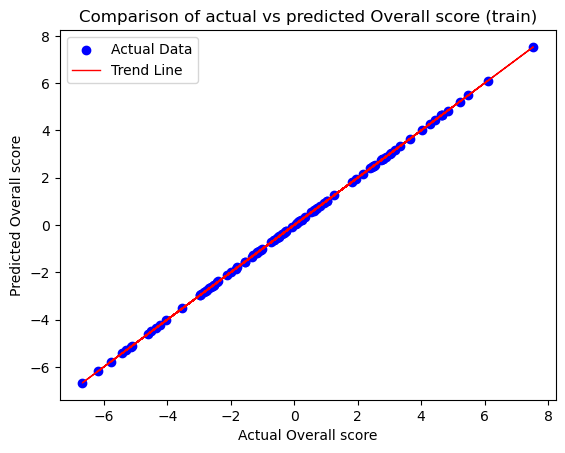

In [1880]:
# Import necessary library.
import matplotlib.pyplot as plt

# Create a scatterplot.
plt.scatter(y_train1,
            y_train1,
            color = 'blue' ,label='Actual Data')

# Regression line (in this case trendline)
plt.plot(y_train1,
         y_pred_train1,
         color='red', linewidth=1, label='Trend Line')  #The plot is two-dimensional with no regression line.Used regression line as trend line.
# Set the title and legends for the graph.  
plt.title("Comparison of actual vs predicted Overall score (train)")
plt.xlabel("Actual Overall score")
plt.ylabel("Predicted Overall score")
plt.legend()

# View the plot.
plt.show()




### **Step 5: Determine the accuracy of the model**

Test the accuracy of the model based on the train data set.

Print the intercept, coefficient, R2, MAE, MSE, and RMSE.

Import the `math` and `metrics` modules. The metrics module is part of the `sklearn` library.

Use the `print()` function to print the values with a docstring to separate values.
    
𝑅2: add the `lm.score()` method and specify the `X_train` and `y_train` data sets.

intercept: `lm.intercept_`

coefficient: `lm.coef_`

MAE: `metrics.mean_absolute_error()`

MSE: `metrics.mean_squared_error()` ( Set the parameter squared=False.)

RMSE: `math.sqrt(metrics.mean_squared_error())`

In [1884]:
# Import metrics module.
import math
from sklearn import metrics

# Print R-squared value.
print("R-squared value (train): ", lm.score(X_train1,
                                            y_train1)) 

# Print the intercept value.
print("\nIntercept value (train):", lm.intercept_) 

# Print the coefficient value.
print("\nCoefficient value (train): ", lm.coef_)


## Use only y_train and not x_train as they have different number of columns.
# Print the MAE.   
print("\nMean Absolute Error (train):", metrics.mean_absolute_error(y_train1,
                                                                    y_pred_train1))  

# Print the MSE. 
print("\nMean Square Error (train):", metrics.mean_squared_error(y_train1,
                                                                 y_pred_train1,
                                                                 squared=False))  

# Print the RMSE. 
rmse_2 = math.sqrt(metrics.mean_squared_error(y_train1,
                                              y_pred_train1))

print("\nRoot Mean Square Error (train):", rmse_2)

R-squared value (train):  0.9999991596504509

Intercept value (train): -0.00020319875478236327

Coefficient value (train):  [-6.24386738e-05  1.00039932e+00  9.99763591e-01  9.99645371e-01
  1.00015296e+00  1.00068942e+00  9.99915001e-01  1.00043581e+00
  1.00020443e+00  1.00008374e+00  1.00015279e+00  1.91547814e-04]

Mean Absolute Error (train): 0.002296745711120603

Mean Square Error (train): 0.002769931523734711

Root Mean Square Error (train): 0.002769931523734711


With a data split of `70:30`, the following results were obtained:

𝑅2=`0.99`: The goodness of fit is approximately `99%` indicating a strong positive correlation between Overall score (𝑌) and 𝑋s.

𝛽0=`-0.00020`: The value of 𝑋s when Overall score (𝑌) is equal to zero.

𝛽1: The value describes the direction and strength of the relationship between the two variables.

MAE and MSE: the respective values are `0.0022` and  `0.0027`.

RMSE: the value is `0.0027`.

**The RMSE and MAE are close to actual mean values, we can assume the model fits the data set accurately.**



### **Step 6: Evaluate the model and make predictions**

#### **a) Evaluate the model**


Create a new variable `y_pred_test` to store the `lim.predict()` method and specify the `X_test` data set.

Create a scatterplot with a regression line similar to the one you’ve created in Step 3.

Ensure you use the correct data sets `y_test` and `y_pred_test`. (For a multiple linear regression model, you have to use y_test instead of X_test.)

Add the color parameter for both data points green.

Set the title and labels for the x-axis and the y-axis.

View the plot.



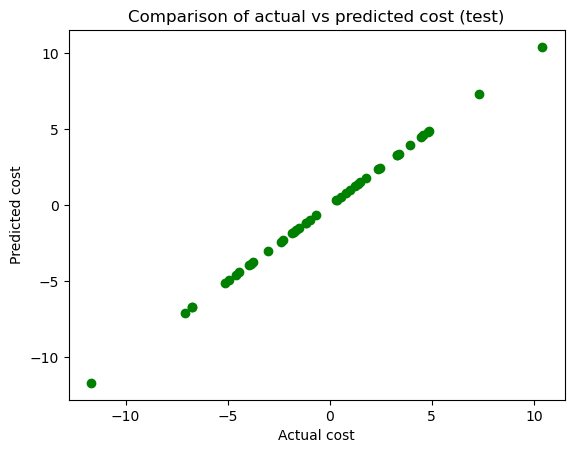

In [1889]:
# Predict the test set values.
y_pred_test = lm.predict(X_test1) 

# Create a scatterplot.
plt.scatter(y_test1, y_pred_test, color = 'green')

# Set the title and legends for the graph.  
plt.title("Comparison of actual vs predicted cost (test)")
plt.xlabel("Actual cost")
plt.ylabel("Predicted cost")

# Print the graph. 
plt.show() 

In [1891]:
# Print R-squared value of the test data.
print("R-squared value (test): ", lm.score(X_test1,
                                           y_test1)) 

# Print the intercept value.
print("\nIntercept value: (test)", lm.intercept_) 

# Print the coefficient value.
print("\nCoefficient value: (test)", lm.coef_)

# Print the MAE.   
print("\nMean Absolute Error (test):", metrics.mean_absolute_error(y_test1,
                                                                   y_pred_test))  

# Print the MSE. 
print("\nMean Square Error (test):", metrics.mean_squared_error(y_test1,
                                                                y_pred_test,
                                                                squared=False))  

# Print the RMSE. 
rmse_2 = math.sqrt(metrics.mean_squared_error(y_test1,
                                              y_pred_test))

print("\nRoot Mean Square Error (test):", rmse_2)

R-squared value (test):  0.9999995778962231

Intercept value: (test) -0.00020319875478236327

Coefficient value: (test) [-6.24386738e-05  1.00039932e+00  9.99763591e-01  9.99645371e-01
  1.00015296e+00  1.00068942e+00  9.99915001e-01  1.00043581e+00
  1.00020443e+00  1.00008374e+00  1.00015279e+00  1.91547814e-04]

Mean Absolute Error (test): 0.002279945845059825

Mean Square Error (test): 0.002734964673968662

Root Mean Square Error (test): 0.002734964673968662


The 𝑅2 is 99%, indicating that the multiple linear regression model is a fairly good fit for the data set. The closer the goodness of fit is to 100%, the better the model is for making predictions. However, it depends on the specific business question.

MAE and MSE: the respective values are `0.0022` and  `0.0027`.

RMSE: the value is `0.0027`.


**The Mean Absolute Error (MAE), Mean Squared Error (MSE), and Root Mean Squared Error (RMSE) for both the train and test sets are closely aligned, indicating consistent performance across datasets. Additionally, the R² values for both models are nearly identical, suggesting that the model maintains a strong explanatory power without overfitting or underfitting. Therefore, we can confidently conclude that the model is a good fit for the data**.


#### **b) Make predictions**


We can also evaluate the actual versus predicted values. For example, compare y_test to y_pred_test.

This comparison can give you an overview of how well the model was fitted to the data set.

**Step-by-Step Instructions:**

Create a DataFrame for Predictions:

Store actual values from `y_test`.

Store predicted values from `y_pred_test`.

Calculate the difference between actual and predicted values.

Organize Data in a DataFrame:

Use `pd.DataFrame()` to structure the results in a readable format.

Display the First 20 Rows:

Use `.head(20)` to preview the top 20 rows of the actual vs. predicted values comparison.

Analyze Prediction Accuracy:

Smaller differences indicate better model performance.

Large differences may suggest errors or need for model improvement.


In [1896]:
# Predict values.
pred_y_df = pd.DataFrame({'Actual value':y_test1,
                          'Predicted value':y_pred_test,
                          'Difference':y_test1-y_pred_test})

# View the DataFrame.
pred_y_df.head(20)

,Actual value,Predicted value,Difference
69,4.59,4.592221,-0.002221
109,3.94,3.939603,0.000397
32,0.33,0.334698,-0.004698
52,2.36,2.356902,0.003098
96,3.28,3.280642,-0.000642
138,-4.42,-4.416687,-0.003313
83,1.78,1.775756,0.004244
115,-3.94,-3.937518,-0.002482
135,-4.58,-4.580372,0.000372
13,-0.65,-0.648757,-0.001243


**As a result of small difference, the model is performing well.**

### **Step 7: Share your findings -------------------------------------------------------------------------**

# Employee Satisfaction and Retention Analysis

## **1. Introduction**
ServiceFirst is a national equipment servicing company with **250 employees**, including both **remote and office-based staff**. Following the pandemic, the company has faced:
- High staff turnover
- Increased recruitment costs
- Loss of in-house experience

To address these challenges, the **People & Culture (P&C) team** conducted an **employee survey** to measure **satisfaction and organizational climate perceptions**. The goal is to apply **advanced analytics and multiple linear regression models** to identify key drivers of satisfaction and **uncover factors influencing employee retention**.

---

## **2. Dataset Overview**
### **Survey Data Summary**
- **Total Employees:** 250
- **Survey Participants:** 196
- **Approved Data for Research:** 142 employees  

The dataset includes **demographic details, satisfaction scores, and key outcome variables related to employee retention**.

### **Initial Data Observations**
- The dataset contains **142 rows and 18 columns**.
- A combination of **numeric and string data types**.
- **No missing values** were detected.
- The **`agree`** column (string) and five categorical variables **(`workloc`, `workleng`, `manag_resp`, `intent_quit`, `sentiment`)** were converted into categorical codes.

---

## **3. Data Wrangling & Cleaning**
- **Converted categorical variables** into numerical representations.
- **Checked for missing and duplicate values** (none found).
- **Identified outliers** using the **Interquartile Range (IQR) method**.

### **Descriptive Statistics**
- **Overall Satisfaction Score:**  
  - Mean: **~0 (-0.000493)**
  - Range: **-11.68 to 27.82** (possible outliers)
- **Intent to Quit:**  
  - Majority of employees are **unsure or do not intend to quit**.
- **Sentiment Analysis:**  
  - Scores range from **1 to 3**.

---

## **4. Outlier Detection**
- Using the **IQR method**, most factors fell within **-5 to 5**.
- **Training** and **Welfare** had the **highest number of outliers**.
- **Overall Score** had **three outliers**, including **one extreme value**.

### **Outlier Handling**
- **Deleted the extreme outlier** to prevent skewing results.
- Retained two **moderate outliers** as they fell within the expected **(-50, 50) range**:
  - **-50:** Extreme dissatisfaction
  - **50:** Extreme satisfaction

This ensured **better accuracy** in insights derived from the data.

---

## **5. Correlation Analysis**
The **correlation matrix** was used to examine relationships between variables. The strongest correlations with **Overall Score** were:
1. **Autonomy** (highest)
2. **Training**
3. **Integration**
4. **Work Pressure**

Based on these findings, **Autonomy** was selected as the **independent variable** for **Simple Linear Regression** as it had the **highest impact on Overall Score**.

---

## **6. Data Preprocessing**
- **Dropped the `agree` and `id` columns** as they were not relevant for analysis.
- **Renamed several columns** for better clarity (e.g., `Work length`).
- **Visualizations** were used to:
  - Examine variable distributions.
  - Determine whether **parametric or non-parametric** tests should be applied.
  - Calculate **Skewness and Kurtosis** to assess distribution symmetry.

### **Key Findings from Distribution Analysis**
- **Normally Distributed Variables:**  
  - For insatnce: `Overall_score`, `customers`, `Autonomy` (slightly left-skewed)
- **Skewed Variables:**  
  - For insatnce: `innovative`, `direct_manag`,...

This distinction was crucial for **selecting appropriate statistical tests** and determining if **transformations** were needed.

---

## **7. Hypothesis Testing**
Four hypotheses were tested using **A/B Testing (t-tests) and Chi-Square Tests**:

1. **Remote vs. Office-Based Employees:** No significant difference in overall satisfaction.
2. **Managers vs. Non-Managers:** No significant difference in satisfaction.
3. **Employees Who Intend to Quit vs. Stay:** No significant difference in satisfaction.
4. **Intent to Quit by Work Location:** No statistically significant difference between remote and office-based employees.

### **Results**
- **P-values greater than 0.05** for all tests indicate **no statistically significant differences**.
- While no strong **categorical effect** was found, other variables (e.g., **Autonomy**) may influence **satisfaction and retention**.

---

## **8. Regression Analysis**
### **Simple Linear Regression**
The dataset was split into a **70:30 train-test ratio**, and a **Simple Linear Regression model** was trained to assess goodness of fit.

#### **Model Details**
- **Predictor (X):** `Autonomy`
- **Dependent Variable (Y):** `Overall Satisfaction Score`
- **R-squared Values:**
  - **Train:** 0.25
  - **Test:** 0.32 (weak relationship)

#### **Findings**
- The test R² was slightly higher than train R², which could indicate:
  - The dataset is **small**, affecting generalization.
  - The test set may contain **samples** the model predicts better.

A **0.25 R² value** means that **only 25% of Overall Score variation** is explained by **Autonomy**, suggesting other factors play a significant role, thus moving to the next step which is Multiple Linear Regression.

---

### **Multiple Linear Regression**
A **Multiple Linear Regression model** was trained to assess the relationship between **Overall Satisfaction Score** and multiple factors.
The dataset was split into a **70:30 train-test ratio**, and a ** Multiple Linear Regression model** was trained to assess goodness of fit.

#### **Multicollinearity Check**
- **Variance Inflation Factor (VIF) > 5** indicates multicollinearity.
- The highest VIF values were found in:
  - `Work_location`
  - `Work_length`
  - `Managerial_responsibility` (**VIF = 13.84**)
  - `Intention_to_quit`
  - `Sentiment`
- **Removed `Managerial_responsibility`**, recalculated VIF, and ensured all remaining variables had **VIF < 5**. Performed the same process untill achieving the VIF less than 5 for the remaining factores.

#### **Final Model Details**
- **Predictors:** `Autonomy`, `Training`, `Welfare`, `Direct Management`, `Work Pressure` and other factors.
- **Dependent Variable (Y):** `Overall Satisfaction Score`
- **R-squared:** **0.99 (Strong relationship)**
- **Key Predictors Affecting Satisfaction:**
  - Training Opportunities
  - Work-Life Balance
  - Management Relationships

#### **Model Performance**
- **High Accuracy (99%)** on the training set.
- **MAE, MSE, RMSE for train and test were closely aligned**, indicating **no overfitting or underfitting**.

Thus, the model was considered a **strong fit** for predicting employee satisfaction.

---

## **9. Model Predictions**
The model was **tested on specific scenarios**, comparing **actual vs. predicted values**.

| **Actual Value** | **Predicted Value** | **Difference** |
|-----------------|-------------------|--------------|
| 4.59           | 4.592221           | -0.002221   |
| 3.94           | 3.939603           | 0.000397    |

 
### **Results**
- **Small error margin (close to zero)** between actual and predicted values.
- Confirmed the model's **accuracy and reliability**.

---

## **10. Key Takeaways**
1. **Training & Career Development:**  
   - Employees with **insufficient training** report **lower satisfaction**.
2. **Management Influence:**  
   - **Direct managers** significantly impact **employee experience**.
3. **Work-Life Balance:**  
   - **High work pressure** correlates with **lower satisfaction** and **higher intent to quit**.
4. **Retention Model Insights:**  
   - The predictive model can **identify at-risk employees** for **early intervention**.

---

## **11. Actionable Recommendations**
✔ **Enhance Training Programs** – Focus on **skill development and career growth**.  
✔ **Improve Managerial Support** – Invest in **leadership training**.  
✔ **Address Work-Life Balance** – Introduce **flexible work arrangements**.  
✔ **Proactive Retention Strategies** – Use **predictive modeling** to identify **at-risk employees** and intervene early.

---

## **12. Conclusion**
Through **statistical analysis and machine learning**, we identified key **drivers of employee satisfaction and retention**. These insights will help **ServiceFirst** design targeted HR strategies to:
- **Improve employee experience**
- **Reduce turnover**
- **Optimize recruitment efforts** 
